# 06 — Canonical Mask-Robustness Dataset Generation

This notebook creates a controlled matched dataset for evaluating sensitivity to mask geometry and spatial placement.

## Experiment design

The experiment uses:

- five canonical paintings reused from Notebook 05;
- three mask families:
  - `scratch_thin`;
  - `loss_small`;
  - `loss_large`;
- five independently generated variants for every painting and mask family;
- one fixed target damaged-area percentage for each mask family.

The configured target percentages are:

- `scratch_thin`: 2.0% of painting-content area;
- `loss_small`: 4.5% of painting-content area;
- `loss_large`: 12.5% of painting-content area.

Each variant uses a deterministic seed while varying:

- geometry;
- placement;
- orientation;
- connected-component structure;
- centroid location;
- border proximity.

Generated masks are adjusted toward the configured target area so that damaged area remains approximately fixed within each painting and mask-family group.

## Responsibilities

This notebook:

1. loads canonical clean-image metadata;
2. recovers the five-painting subset established by Notebook 05;
3. reconstructs the canonical content bounding box from preprocessing metadata;
4. constructs the expected 75-case robustness design;
5. tests one complete five-variant robustness group;
6. generates the full mask-robustness dataset;
7. generates corresponding damaged images;
8. records deterministic seeds, morphology, and location statistics;
9. validates target area, dimensions, binary masks, fill behaviour, and checksums;
10. tests whether variants within each robustness group are genuinely distinct;
11. validates the complete file inventory;
12. writes one canonical metadata CSV, one canonical audit CSV, one JSON manifest, one Markdown report, and canonical figures.

## Canonical outputs

```text
data/processed/
├── masks/
│   └── mask_robustness/
├── damaged/
│   └── mask_robustness/
└── metadata/
    └── metadata_mask_robustness.csv

outputs/
├── 06_mask_robustness/
│   └── mask_robustness_audit.csv
├── figures/
│   └── mask_robustness/
└── reports/
    ├── mask_robustness_manifest.json
    └── mask_robustness_report.md
```

## Scope boundary

This notebook generates and validates controlled robustness cases only.

Restoration generation, model comparisons, metric variance, robustness curves, statistical analysis, and thesis-level interpretation are deferred to later notebooks.

In [1]:
from pathlib import Path
import sys


def find_project_root(
    start_path: Path,
) -> Path:
    current_path = start_path.resolve()

    for candidate_path in [
        current_path,
        *current_path.parents,
    ]:
        if (
            (candidate_path / "config").is_dir()
            and (candidate_path / "src").is_dir()
        ):
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Expected a parent directory containing "
        "both 'config/' and 'src/'."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

SRC_DIR = PROJECT_ROOT / "src"

EXPERIMENT_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)


if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


if not SRC_DIR.exists():
    raise FileNotFoundError(
        "Source directory does not exist: "
        f"{SRC_DIR}"
    )


if not EXPERIMENT_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Experiment configuration does not exist: "
        f"{EXPERIMENT_CONFIG_PATH}"
    )


mask_robustness_module_path = (
    SRC_DIR
    / "restoration_eval"
    / "mask_robustness.py"
)


if not mask_robustness_module_path.exists():
    raise FileNotFoundError(
        "Mask-robustness module does not exist: "
        f"{mask_robustness_module_path}"
    )


print("Environment configured")
print("----------------------")
print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print(
    "Experiment configuration:",
    EXPERIMENT_CONFIG_PATH,
)
print(
    "Mask-robustness module:",
    mask_robustness_module_path,
)

Environment configured
----------------------
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Experiment configuration: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Mask-robustness module: D:\Masters\FH\Thesis\painting-restoration-eval\src\restoration_eval\mask_robustness.py


In [2]:
import json
import shutil
from datetime import datetime, timezone
from textwrap import dedent

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image

from restoration_eval.mask_robustness import (
    DEFAULT_BASE_MASK_TYPES,
    DEFAULT_VARIANTS_PER_MASK_TYPE,
    GENERATOR_NAME,
    GENERATOR_VERSION,
    audit_mask_robustness_inventory,
    create_mask_robustness_dataset,
    validate_mask_robustness_dataset,
)


with EXPERIMENT_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as configuration_file:
    experiment_config = yaml.safe_load(
        configuration_file
    )


if not isinstance(
    experiment_config,
    dict,
):
    raise ValueError(
        "Experiment configuration must contain "
        "a YAML mapping."
    )


required_config_sections = [
    "experiment",
    "paths",
    "dataset",
    "preprocessing",
]


missing_config_sections = [
    section_name
    for section_name in required_config_sections
    if section_name not in experiment_config
]


if missing_config_sections:
    raise ValueError(
        "Configuration is missing required sections: "
        f"{missing_config_sections}"
    )


def resolve_config_path(
    path_value: str | Path,
) -> Path:
    resolved_path = Path(
        path_value
    )

    if resolved_path.is_absolute():
        return resolved_path

    return (
        PROJECT_ROOT
        / resolved_path
    )


experiment_identity_config = (
    experiment_config[
        "experiment"
    ]
)

paths_config = experiment_config[
    "paths"
]

preprocessing_config = (
    experiment_config[
        "preprocessing"
    ]
)

damage_size_config = experiment_config.get(
    "damage_size_sensitivity",
    {},
)

mask_robustness_config = experiment_config.get(
    "mask_robustness",
    {},
)


if not damage_size_config:
    raise ValueError(
        "Configuration section "
        "'damage_size_sensitivity' is required "
        "to recover Notebook 05's canonical subset."
    )


if not mask_robustness_config:
    raise ValueError(
        "Configuration section 'mask_robustness' "
        "is missing or empty."
    )


experiment_name = str(
    experiment_identity_config.get(
        "name",
        "painting_restoration_50_subset",
    )
)

experiment_version = str(
    experiment_identity_config.get(
        "version",
        "1.0",
    )
)

config_version = str(
    experiment_config.get(
        "config_version",
        experiment_version,
    )
)


target_size = int(
    preprocessing_config.get(
        "output_size",
        experiment_identity_config.get(
            "image_size",
            768,
        ),
    )
)


processed_metadata_dir = (
    resolve_config_path(
        paths_config.get(
            "processed_metadata_dir",
            "data/processed/metadata",
        )
    )
)


processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)


damage_size_metadata_path = (
    resolve_config_path(
        damage_size_config.get(
            "metadata_path",
            (
                "data/processed/metadata/"
                "metadata_damage_size_sensitivity.csv"
            ),
        )
    )
)


robustness_metadata_path = (
    resolve_config_path(
        mask_robustness_config.get(
            "metadata_path",
            (
                "data/processed/metadata/"
                "metadata_mask_robustness.csv"
            ),
        )
    )
)


robustness_mask_dir = (
    resolve_config_path(
        mask_robustness_config.get(
            "mask_dir",
            (
                "data/processed/masks/"
                "mask_robustness"
            ),
        )
    )
)


robustness_damaged_dir = (
    resolve_config_path(
        mask_robustness_config.get(
            "damaged_dir",
            (
                "data/processed/damaged/"
                "mask_robustness"
            ),
        )
    )
)


canonical_figures_root = (
    resolve_config_path(
        paths_config.get(
            "figures_dir",
            "outputs/figures",
        )
    )
)


canonical_reports_root = (
    resolve_config_path(
        paths_config.get(
            "reports_dir",
            "outputs/reports",
        )
    )
)


robustness_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "06_mask_robustness"
)


robustness_figure_dir = (
    canonical_figures_root
    / "mask_robustness"
)


variant_grid_dir = (
    robustness_figure_dir
    / "variant_grids"
)


robustness_audit_path = (
    robustness_output_dir
    / "mask_robustness_audit.csv"
)


robustness_manifest_path = (
    canonical_reports_root
    / "mask_robustness_manifest.json"
)


robustness_report_path = (
    canonical_reports_root
    / "mask_robustness_report.md"
)


temporary_test_dir = (
    robustness_output_dir
    / "_test"
)


temporary_test_mask_dir = (
    temporary_test_dir
    / "masks"
)


temporary_test_damaged_dir = (
    temporary_test_dir
    / "damaged"
)


for output_directory in [
    robustness_metadata_path.parent,
    robustness_mask_dir,
    robustness_damaged_dir,
    robustness_output_dir,
    robustness_figure_dir,
    variant_grid_dir,
    canonical_reports_root,
]:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


base_mask_types = tuple(
    str(mask_type)
    for mask_type
    in mask_robustness_config.get(
        "base_mask_types",
        DEFAULT_BASE_MASK_TYPES,
    )
)


target_percentages = {
    str(mask_type): float(
        target_percentage
    )
    for mask_type, target_percentage
    in mask_robustness_config.get(
        "target_percentages",
        {
            "scratch_thin": 2.0,
            "loss_small": 4.5,
            "loss_large": 12.5,
        },
    ).items()
}


variants_per_mask_type = int(
    mask_robustness_config.get(
        "variants_per_mask_type",
        DEFAULT_VARIANTS_PER_MASK_TYPE,
    )
)


expected_painting_count = int(
    mask_robustness_config.get(
        "expected_painting_count",
        5,
    )
)


global_seed = int(
    mask_robustness_config.get(
        "global_seed",
        20260606,
    )
)


maximum_percentage_error = float(
    mask_robustness_config.get(
        "maximum_percentage_error",
        0.50,
    )
)


damage_fill_strategy = str(
    mask_robustness_config.get(
        "fill_strategy",
        "constant_rgb",
    )
)


damage_fill_color = tuple(
    int(channel_value)
    for channel_value
    in mask_robustness_config.get(
        "fill_color",
        [255, 255, 255],
    )
)


expected_mask_types = (
    "scratch_thin",
    "loss_small",
    "loss_large",
)


expected_mask_type_count = len(
    base_mask_types
)


expected_group_count = (
    expected_painting_count
    * expected_mask_type_count
)


expected_case_count = (
    expected_group_count
    * variants_per_mask_type
)


configuration_validation_records = [
    {
        "check": "positive_target_size",
        "passed": target_size > 0,
        "observed": target_size,
        "expected": "> 0",
    },
    {
        "check": "positive_painting_count",
        "passed": (
            expected_painting_count
            > 0
        ),
        "observed": expected_painting_count,
        "expected": "> 0",
    },
    {
        "check": "canonical_mask_types",
        "passed": (
            base_mask_types
            == expected_mask_types
        ),
        "observed": str(
            base_mask_types
        ),
        "expected": str(
            expected_mask_types
        ),
    },
    {
        "check": "target_percentage_keys",
        "passed": (
            set(
                target_percentages
            )
            == set(
                base_mask_types
            )
        ),
        "observed": str(
            sorted(
                target_percentages
            )
        ),
        "expected": str(
            sorted(
                base_mask_types
            )
        ),
    },
    {
        "check": "valid_target_percentages",
        "passed": all(
            0
            < target_percentage
            < 100
            for target_percentage
            in target_percentages.values()
        ),
        "observed": str(
            target_percentages
        ),
        "expected": "all values between 0 and 100",
    },
    {
        "check": "minimum_variant_count",
        "passed": (
            variants_per_mask_type
            >= 2
        ),
        "observed": variants_per_mask_type,
        "expected": ">= 2",
    },
    {
        "check": "rgb_fill_length",
        "passed": (
            len(
                damage_fill_color
            )
            == 3
        ),
        "observed": len(
            damage_fill_color
        ),
        "expected": 3,
    },
    {
        "check": "valid_rgb_fill_values",
        "passed": all(
            0
            <= channel_value
            <= 255
            for channel_value
            in damage_fill_color
        ),
        "observed": str(
            damage_fill_color
        ),
        "expected": "all values between 0 and 255",
    },
    {
        "check": "nonnegative_percentage_error",
        "passed": (
            maximum_percentage_error
            >= 0
        ),
        "observed": maximum_percentage_error,
        "expected": ">= 0",
    },
    {
        "check": "expected_case_count",
        "passed": (
            expected_case_count
            == 75
        ),
        "observed": expected_case_count,
        "expected": 75,
    },
]


configuration_validation_df = pd.DataFrame(
    configuration_validation_records
)


failed_configuration_validation_df = (
    configuration_validation_df.loc[
        ~configuration_validation_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


print("Mask-robustness configuration")
print("-----------------------------")
print("Generator:", GENERATOR_NAME)
print(
    "Generator version:",
    GENERATOR_VERSION,
)
print("Target size:", target_size)
print(
    "Selected painting count:",
    expected_painting_count,
)
print(
    "Mask types:",
    base_mask_types,
)
print(
    "Target percentages:",
    target_percentages,
)
print(
    "Variants per mask type:",
    variants_per_mask_type,
)
print(
    "Expected robustness groups:",
    expected_group_count,
)
print(
    "Expected cases:",
    expected_case_count,
)
print("Global seed:", global_seed)
print(
    "Maximum percentage error:",
    maximum_percentage_error,
)
print(
    "Canonical metadata:",
    robustness_metadata_path,
)
print(
    "Canonical mask directory:",
    robustness_mask_dir,
)
print(
    "Canonical damaged directory:",
    robustness_damaged_dir,
)
print(
    "Canonical audit:",
    robustness_audit_path,
)
print(
    "Canonical figure directory:",
    robustness_figure_dir,
)
print(
    "Canonical manifest:",
    robustness_manifest_path,
)
print(
    "Canonical report:",
    robustness_report_path,
)


print("\nConfiguration validation")
print("------------------------")

display(
    configuration_validation_df
)


if not failed_configuration_validation_df.empty:
    display(
        failed_configuration_validation_df
    )

    raise ValueError(
        "Notebook 06 configuration validation failed."
    )


print(
    "\nNotebook 06 configuration passed."
)

Mask-robustness configuration
-----------------------------
Generator: mask_robustness
Generator version: 1.1.0
Target size: 768
Selected painting count: 5
Mask types: ('scratch_thin', 'loss_small', 'loss_large')
Target percentages: {'scratch_thin': 2.0, 'loss_small': 4.5, 'loss_large': 12.5}
Variants per mask type: 5
Expected robustness groups: 15
Expected cases: 75
Global seed: 20260606
Maximum percentage error: 0.5
Canonical metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_mask_robustness.csv
Canonical mask directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\mask_robustness
Canonical damaged directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\damaged\mask_robustness
Canonical audit: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\06_mask_robustness\mask_robustness_audit.csv
Canonical figure directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\mask_robustness
Canonical

,check,passed,observed,expected
0,positive_target_size,True,768,> 0
1,positive_painting_count,True,5,> 0
2,canonical_mask_types,True,"('scratch_thin', 'loss_small', 'loss_large')","('scratch_thin', 'loss_small', 'loss_large')"
3,target_percentage_keys,True,"['loss_large', 'loss_small', 'scratch_thin']","['loss_large', 'loss_small', 'scratch_thin']"
4,valid_target_percentages,True,"{'scratch_thin': 2.0, 'loss_small': 4.5, 'loss...",all values between 0 and 100
5,minimum_variant_count,True,5,>= 2
6,rgb_fill_length,True,3,3
7,valid_rgb_fill_values,True,"(255, 255, 255)",all values between 0 and 255
8,nonnegative_percentage_error,True,0.5,>= 0
9,expected_case_count,True,75,75



Notebook 06 configuration passed.


In [3]:
# Load canonical source metadata and recover Notebook 05's five paintings

required_input_paths = [
    processed_metadata_path,
    damage_size_metadata_path,
]


missing_input_paths = [
    input_path
    for input_path in required_input_paths
    if not input_path.exists()
]


if missing_input_paths:
    raise FileNotFoundError(
        "Required Notebook 06 inputs are missing: "
        f"{missing_input_paths}"
    )


processed_metadata_df = pd.read_csv(
    processed_metadata_path
)


damage_size_metadata_df = pd.read_csv(
    damage_size_metadata_path
)


required_processed_columns = [
    "painting_id",
    "processed_filename",
    "processed_path",
    "processed_width",
    "processed_height",
    "content_width",
    "content_height",
]


required_damage_size_columns = [
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "status",
]


missing_processed_columns = [
    column_name
    for column_name
    in required_processed_columns
    if column_name
    not in processed_metadata_df.columns
]


missing_damage_size_columns = [
    column_name
    for column_name
    in required_damage_size_columns
    if column_name
    not in damage_size_metadata_df.columns
]


if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_columns}"
    )


if missing_damage_size_columns:
    raise ValueError(
        "Notebook 05 metadata is missing required columns: "
        f"{missing_damage_size_columns}"
    )


processed_metadata_df[
    "painting_id"
] = (
    processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
)


damage_size_metadata_df[
    "painting_id"
] = (
    damage_size_metadata_df[
        "painting_id"
    ]
    .astype(str)
)


duplicate_processed_paintings_df = (
    processed_metadata_df.loc[
        processed_metadata_df[
            "painting_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_processed_paintings_df.empty:
    display(
        duplicate_processed_paintings_df
    )

    raise ValueError(
        "Processed metadata contains duplicate "
        "painting IDs."
    )


invalid_damage_size_status_df = (
    damage_size_metadata_df.loc[
        damage_size_metadata_df[
            "status"
        ]
        .astype(str)
        .ne("ok")
    ]
    .copy()
)


if not invalid_damage_size_status_df.empty:
    display(
        invalid_damage_size_status_df
    )

    raise ValueError(
        "Notebook 05 metadata contains "
        "unsuccessful generation rows."
    )


canonical_painting_ids = sorted(
    damage_size_metadata_df[
        "painting_id"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


if (
    len(
        canonical_painting_ids
    )
    != expected_painting_count
):
    raise ValueError(
        "Notebook 05 metadata does not identify "
        f"exactly {expected_painting_count} paintings: "
        f"observed={len(canonical_painting_ids)}"
    )


missing_from_processed_metadata = sorted(
    set(
        canonical_painting_ids
    )
    - set(
        processed_metadata_df[
            "painting_id"
        ]
        .astype(str)
    )
)


if missing_from_processed_metadata:
    raise ValueError(
        "Notebook 05 paintings are missing from "
        "processed metadata: "
        f"{missing_from_processed_metadata}"
    )


robustness_processed_metadata_df = (
    processed_metadata_df.loc[
        processed_metadata_df[
            "painting_id"
        ]
        .isin(
            canonical_painting_ids
        )
    ]
    .copy()
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


if (
    len(
        robustness_processed_metadata_df
    )
    != expected_painting_count
):
    raise ValueError(
        "Robustness subset row count is invalid: "
        f"observed={len(robustness_processed_metadata_df)}, "
        f"expected={expected_painting_count}"
    )


numeric_source_columns = [
    "processed_width",
    "processed_height",
    "content_width",
    "content_height",
]


for column_name in numeric_source_columns:
    robustness_processed_metadata_df[
        column_name
    ] = pd.to_numeric(
        robustness_processed_metadata_df[
            column_name
        ],
        errors="raise",
    ).astype(int)


# Preprocessing preserves aspect ratio and applies centered padding.
# Reconstruct the content bounding box required by mask_robustness.py.

horizontal_padding_df = (
    robustness_processed_metadata_df[
        "processed_width"
    ]
    - robustness_processed_metadata_df[
        "content_width"
    ]
)


vertical_padding_df = (
    robustness_processed_metadata_df[
        "processed_height"
    ]
    - robustness_processed_metadata_df[
        "content_height"
    ]
)


if (
    horizontal_padding_df.lt(0).any()
    or vertical_padding_df.lt(0).any()
):
    raise ValueError(
        "Content dimensions cannot exceed "
        "processed-image dimensions."
    )


robustness_processed_metadata_df[
    "content_x_min"
] = (
    horizontal_padding_df
    // 2
).astype(int)


robustness_processed_metadata_df[
    "content_y_min"
] = (
    vertical_padding_df
    // 2
).astype(int)


robustness_processed_metadata_df[
    "content_x_max"
] = (
    robustness_processed_metadata_df[
        "content_x_min"
    ]
    + robustness_processed_metadata_df[
        "content_width"
    ]
).astype(int)


robustness_processed_metadata_df[
    "content_y_max"
] = (
    robustness_processed_metadata_df[
        "content_y_min"
    ]
    + robustness_processed_metadata_df[
        "content_height"
    ]
).astype(int)


missing_clean_file_records = []
invalid_dimension_records = []
invalid_content_box_records = []


for metadata_row in (
    robustness_processed_metadata_df
    .itertuples(
        index=False
    )
):
    painting_id = str(
        metadata_row.painting_id
    )


    clean_image_path = Path(
        str(
            metadata_row.processed_path
        )
    )


    if not clean_image_path.is_absolute():
        clean_image_path = (
            PROJECT_ROOT
            / clean_image_path
        )


    if not clean_image_path.exists():
        missing_clean_file_records.append(
            {
                "painting_id": painting_id,
                "processed_path": str(
                    clean_image_path
                ),
            }
        )

        continue


    with Image.open(
        clean_image_path
    ) as opened_clean_image:
        observed_width, observed_height = (
            opened_clean_image.size
        )


    metadata_width = int(
        metadata_row.processed_width
    )

    metadata_height = int(
        metadata_row.processed_height
    )


    if (
        observed_width
        != metadata_width
        or observed_height
        != metadata_height
        or observed_width
        != target_size
        or observed_height
        != target_size
    ):
        invalid_dimension_records.append(
            {
                "painting_id": painting_id,
                "metadata_width": metadata_width,
                "metadata_height": metadata_height,
                "observed_width": observed_width,
                "observed_height": observed_height,
                "expected_width": target_size,
                "expected_height": target_size,
            }
        )


    content_box = (
        int(
            metadata_row.content_x_min
        ),
        int(
            metadata_row.content_y_min
        ),
        int(
            metadata_row.content_x_max
        ),
        int(
            metadata_row.content_y_max
        ),
    )


    (
        content_x_min,
        content_y_min,
        content_x_max,
        content_y_max,
    ) = content_box


    content_box_valid = (
        0
        <= content_x_min
        < content_x_max
        <= observed_width
        and 0
        <= content_y_min
        < content_y_max
        <= observed_height
        and (
            content_x_max
            - content_x_min
            == int(
                metadata_row.content_width
            )
        )
        and (
            content_y_max
            - content_y_min
            == int(
                metadata_row.content_height
            )
        )
    )


    if not content_box_valid:
        invalid_content_box_records.append(
            {
                "painting_id": painting_id,
                "content_box": content_box,
                "content_width": int(
                    metadata_row.content_width
                ),
                "content_height": int(
                    metadata_row.content_height
                ),
                "image_size": (
                    observed_width,
                    observed_height,
                ),
            }
        )


missing_clean_files_df = pd.DataFrame(
    missing_clean_file_records
)


invalid_dimensions_df = pd.DataFrame(
    invalid_dimension_records
)


invalid_content_boxes_df = pd.DataFrame(
    invalid_content_box_records
)


selected_damage_size_distribution_df = (
    damage_size_metadata_df.loc[
        damage_size_metadata_df[
            "painting_id"
        ]
        .isin(
            canonical_painting_ids
        )
    ]
    .groupby(
        [
            "painting_id",
            "base_mask_type",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        target_level_count=(
            "target_percentage_content",
            "nunique",
        ),
    )
    .reset_index()
)


subset_display_columns = [
    column_name
    for column_name in [
        "painting_id",
        "title",
        "artist",
        "category",
        "style_group",
        "genre",
        "processed_filename",
        "processed_path",
        "processed_width",
        "processed_height",
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
        "content_width",
        "content_height",
    ]
    if column_name
    in robustness_processed_metadata_df.columns
]


metadata_gate_summary_df = pd.DataFrame(
    [
        {
            "check": "selected_paintings",
            "observed": len(
                robustness_processed_metadata_df
            ),
            "expected": expected_painting_count,
            "passed": (
                len(
                    robustness_processed_metadata_df
                )
                == expected_painting_count
            ),
        },
        {
            "check": "unique_selected_paintings",
            "observed": (
                robustness_processed_metadata_df[
                    "painting_id"
                ]
                .astype(str)
                .nunique()
            ),
            "expected": expected_painting_count,
            "passed": (
                robustness_processed_metadata_df[
                    "painting_id"
                ]
                .astype(str)
                .nunique()
                == expected_painting_count
            ),
        },
        {
            "check": "missing_clean_files",
            "observed": len(
                missing_clean_files_df
            ),
            "expected": 0,
            "passed": (
                missing_clean_files_df.empty
            ),
        },
        {
            "check": "invalid_image_dimensions",
            "observed": len(
                invalid_dimensions_df
            ),
            "expected": 0,
            "passed": (
                invalid_dimensions_df.empty
            ),
        },
        {
            "check": "invalid_content_boxes",
            "observed": len(
                invalid_content_boxes_df
            ),
            "expected": 0,
            "passed": (
                invalid_content_boxes_df.empty
            ),
        },
        {
            "check": "notebook_05_case_rows",
            "observed": len(
                damage_size_metadata_df
            ),
            "expected": (
                expected_painting_count
                * 7
            ),
            "passed": (
                len(
                    damage_size_metadata_df
                )
                == (
                    expected_painting_count
                    * 7
                )
            ),
        },
    ]
)


print("Canonical Notebook 05 paintings reused")
print("---------------------------------------")

display(
    robustness_processed_metadata_df[
        subset_display_columns
    ]
)


print("\nRecovered Notebook 05 distribution")
print("-----------------------------------")

display(
    selected_damage_size_distribution_df
)


print("\nMetadata gate summary")
print("---------------------")

display(
    metadata_gate_summary_df
)


failed_metadata_gates_df = (
    metadata_gate_summary_df.loc[
        ~metadata_gate_summary_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_metadata_gates_df.empty:
    if not missing_clean_files_df.empty:
        print("\nMissing clean images")

        display(
            missing_clean_files_df
        )


    if not invalid_dimensions_df.empty:
        print("\nInvalid image dimensions")

        display(
            invalid_dimensions_df
        )


    if not invalid_content_boxes_df.empty:
        print("\nInvalid reconstructed content boxes")

        display(
            invalid_content_boxes_df
        )


    display(
        failed_metadata_gates_df
    )


    raise ValueError(
        "Notebook 06 source metadata gate failed."
    )


print(
    "\nNotebook 06 five-painting metadata gate passed."
)

Canonical Notebook 05 paintings reused
---------------------------------------


,painting_id,title,artist,category,processed_filename,processed_path,processed_width,processed_height,content_x_min,content_y_min,content_x_max,content_y_max,content_width,content_height
0,p001,Juan de Pareja,Diego Velázquez,portrait_figure,p001_clean.png,data/processed/clean/p001_clean.png,768,768,52,0,715,768,663,768
1,p018,Classical Landscape with Figures,Henri Mauperché,landscape_natural,p018_clean.png,data/processed/clean/p018_clean.png,768,768,0,130,768,637,768,507
2,p026,View of a Village along a River,attributed to Jan Brueghel I,architecture_structured,p026_clean.png,data/processed/clean/p026_clean.png,768,768,0,119,768,648,768,529
3,p039,Painting with Troika,Wassily Kandinsky,abstraction_surrealism,p039_clean.png,data/processed/clean/p039_clean.png,768,768,0,102,768,666,768,564
4,p043,The Card Players,Paul Cézanne,high_texture_brushwork,p043_clean.png,data/processed/clean/p043_clean.png,768,768,0,78,768,689,768,611



Recovered Notebook 05 distribution
-----------------------------------


,painting_id,base_mask_type,case_count,target_level_count
0,p001,loss_large,7,7
1,p018,loss_large,7,7
2,p026,loss_large,7,7
3,p039,loss_large,7,7
4,p043,loss_large,7,7



Metadata gate summary
---------------------


,check,observed,expected,passed
0,selected_paintings,5,5,True
1,unique_selected_paintings,5,5,True
2,missing_clean_files,0,0,True
3,invalid_image_dimensions,0,0,True
4,invalid_content_boxes,0,0,True
5,notebook_05_case_rows,35,35,True



Notebook 06 five-painting metadata gate passed.


In [4]:
# Construct the expected 75-case mask-robustness design in memory

expected_case_records = []


for painting_id in sorted(
    robustness_processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .tolist()
):
    for mask_type_index, mask_type in enumerate(
        base_mask_types,
        start=1,
    ):
        robustness_group_id = (
            f"{painting_id}"
            f"__{mask_type}"
        )


        for variant_index in range(
            1,
            variants_per_mask_type + 1,
        ):
            variant_token = (
                f"variant_{variant_index:02d}"
            )

            case_id = (
                f"{robustness_group_id}"
                f"__{variant_token}"
            )


            expected_case_records.append(
                {
                    "case_id": case_id,
                    "variant_id": case_id,
                    "robustness_group_id": (
                        robustness_group_id
                    ),
                    "painting_id": (
                        painting_id
                    ),
                    "base_mask_type": (
                        mask_type
                    ),
                    "mask_type_index": int(
                        mask_type_index
                    ),
                    "variant_index": int(
                        variant_index
                    ),
                    "target_percentage_content": float(
                        target_percentages[
                            mask_type
                        ]
                    ),
                    "global_seed": int(
                        global_seed
                    ),
                    "seed_policy": (
                        "sha256(global_seed || "
                        "painting_id || mask_type || "
                        "mask_type_index || variant_index)"
                    ),
                    "expected_mask_filename": (
                        f"{case_id}_mask.png"
                    ),
                    "expected_damaged_filename": (
                        f"{case_id}_damaged.png"
                    ),
                }
            )


expected_case_manifest_df = pd.DataFrame(
    expected_case_records
)


if (
    len(
        expected_case_manifest_df
    )
    != expected_case_count
):
    raise ValueError(
        "Expected-case design row count is invalid: "
        f"observed={len(expected_case_manifest_df)}, "
        f"expected={expected_case_count}"
    )


duplicate_expected_case_rows_df = (
    expected_case_manifest_df.loc[
        expected_case_manifest_df[
            "case_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_expected_case_rows_df.empty:
    display(
        duplicate_expected_case_rows_df
    )

    raise ValueError(
        "Expected-case design contains "
        "duplicate case IDs."
    )


expected_group_distribution_df = (
    expected_case_manifest_df
    .groupby(
        [
            "painting_id",
            "base_mask_type",
            "robustness_group_id",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        variant_count=(
            "variant_index",
            "nunique",
        ),
        minimum_variant_index=(
            "variant_index",
            "min",
        ),
        maximum_variant_index=(
            "variant_index",
            "max",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
    )
    .reset_index()
)


invalid_group_distribution_df = (
    expected_group_distribution_df.loc[
        (
            expected_group_distribution_df[
                "case_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            expected_group_distribution_df[
                "variant_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            expected_group_distribution_df[
                "minimum_variant_index"
            ]
            != 1
        )
        |
        (
            expected_group_distribution_df[
                "maximum_variant_index"
            ]
            != variants_per_mask_type
        )
    ]
    .copy()
)


expected_family_distribution_df = (
    expected_case_manifest_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        robustness_group_count=(
            "robustness_group_id",
            "nunique",
        ),
        variants_per_group=(
            "variant_index",
            "nunique",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
    )
    .reset_index()
)


expected_cases_per_family = (
    expected_painting_count
    * variants_per_mask_type
)


invalid_family_distribution_df = (
    expected_family_distribution_df.loc[
        (
            expected_family_distribution_df[
                "case_count"
            ]
            != expected_cases_per_family
        )
        |
        (
            expected_family_distribution_df[
                "painting_count"
            ]
            != expected_painting_count
        )
        |
        (
            expected_family_distribution_df[
                "robustness_group_count"
            ]
            != expected_painting_count
        )
        |
        (
            expected_family_distribution_df[
                "variants_per_group"
            ]
            != variants_per_mask_type
        )
    ]
    .copy()
)


observed_mask_type_order = tuple(
    expected_family_distribution_df[
        "base_mask_type"
    ]
    .astype(str)
    .tolist()
)


expected_design_summary_df = pd.DataFrame(
    [
        {
            "check": "case_count",
            "observed": len(
                expected_case_manifest_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    expected_case_manifest_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                expected_case_manifest_df[
                    "case_id"
                ]
                .nunique()
            ),
            "expected": expected_case_count,
            "passed": (
                expected_case_manifest_df[
                    "case_id"
                ]
                .nunique()
                == expected_case_count
            ),
        },
        {
            "check": "painting_count",
            "observed": (
                expected_case_manifest_df[
                    "painting_id"
                ]
                .nunique()
            ),
            "expected": expected_painting_count,
            "passed": (
                expected_case_manifest_df[
                    "painting_id"
                ]
                .nunique()
                == expected_painting_count
            ),
        },
        {
            "check": "mask_family_count",
            "observed": (
                expected_case_manifest_df[
                    "base_mask_type"
                ]
                .nunique()
            ),
            "expected": expected_mask_type_count,
            "passed": (
                expected_case_manifest_df[
                    "base_mask_type"
                ]
                .nunique()
                == expected_mask_type_count
            ),
        },
        {
            "check": "robustness_group_count",
            "observed": (
                expected_case_manifest_df[
                    "robustness_group_id"
                ]
                .nunique()
            ),
            "expected": expected_group_count,
            "passed": (
                expected_case_manifest_df[
                    "robustness_group_id"
                ]
                .nunique()
                == expected_group_count
            ),
        },
        {
            "check": "mask_type_order",
            "observed": str(
                observed_mask_type_order
            ),
            "expected": str(
                base_mask_types
            ),
            "passed": (
                observed_mask_type_order
                == base_mask_types
            ),
        },
        {
            "check": "invalid_group_rows",
            "observed": len(
                invalid_group_distribution_df
            ),
            "expected": 0,
            "passed": (
                invalid_group_distribution_df.empty
            ),
        },
        {
            "check": "invalid_family_rows",
            "observed": len(
                invalid_family_distribution_df
            ),
            "expected": 0,
            "passed": (
                invalid_family_distribution_df.empty
            ),
        },
    ]
)


print("Expected robustness design")
print("--------------------------")

display(
    expected_design_summary_df
)


print("\nExpected family distribution")
print("----------------------------")

display(
    expected_family_distribution_df
)


print("\nExpected group distribution")
print("---------------------------")

display(
    expected_group_distribution_df
)


failed_expected_design_df = (
    expected_design_summary_df.loc[
        ~expected_design_summary_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_expected_design_df.empty:
    if not invalid_group_distribution_df.empty:
        print("\nInvalid robustness groups")

        display(
            invalid_group_distribution_df
        )


    if not invalid_family_distribution_df.empty:
        print("\nInvalid mask-family distribution")

        display(
            invalid_family_distribution_df
        )


    display(
        failed_expected_design_df
    )


    raise ValueError(
        "Expected 75-case mask-robustness "
        "design validation failed."
    )


print(
    "\nExpected 75-case robustness design passed."
)

Expected robustness design
--------------------------


,check,observed,expected,passed
0,case_count,75,75,True
1,unique_case_ids,75,75,True
2,painting_count,5,5,True
3,mask_family_count,3,3,True
4,robustness_group_count,15,15,True
5,mask_type_order,"('scratch_thin', 'loss_small', 'loss_large')","('scratch_thin', 'loss_small', 'loss_large')",True
6,invalid_group_rows,0,0,True
7,invalid_family_rows,0,0,True



Expected family distribution
----------------------------


,base_mask_type,case_count,painting_count,robustness_group_count,variants_per_group,target_percentage_content
0,scratch_thin,25,5,5,5,2.0
1,loss_small,25,5,5,5,4.5
2,loss_large,25,5,5,5,12.5



Expected group distribution
---------------------------


,painting_id,base_mask_type,robustness_group_id,case_count,variant_count,minimum_variant_index,maximum_variant_index,target_percentage_content
0,p001,loss_large,p001__loss_large,5,5,1,5,12.5
1,p001,loss_small,p001__loss_small,5,5,1,5,4.5
2,p001,scratch_thin,p001__scratch_thin,5,5,1,5,2.0
3,p018,loss_large,p018__loss_large,5,5,1,5,12.5
4,p018,loss_small,p018__loss_small,5,5,1,5,4.5
5,p018,scratch_thin,p018__scratch_thin,5,5,1,5,2.0
6,p026,loss_large,p026__loss_large,5,5,1,5,12.5
7,p026,loss_small,p026__loss_small,5,5,1,5,4.5
8,p026,scratch_thin,p026__scratch_thin,5,5,1,5,2.0
9,p039,loss_large,p039__loss_large,5,5,1,5,12.5



Expected 75-case robustness design passed.


In [5]:
# Generate one complete five-variant robustness group

example_painting_id = str(
    robustness_processed_metadata_df[
        "painting_id"
    ]
    .iloc[0]
)


example_mask_type = (
    "loss_small"
)


if example_mask_type not in base_mask_types:
    raise ValueError(
        "Example mask type is not configured: "
        f"{example_mask_type}"
    )


example_processed_metadata_df = (
    robustness_processed_metadata_df.loc[
        robustness_processed_metadata_df[
            "painting_id"
        ]
        .astype(str)
        .eq(
            example_painting_id
        )
    ]
    .copy()
    .reset_index(drop=True)
)


if (
    len(
        example_processed_metadata_df
    )
    != 1
):
    raise ValueError(
        "Example metadata must contain "
        "exactly one painting."
    )


if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )


temporary_test_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)


temporary_test_damaged_dir.mkdir(
    parents=True,
    exist_ok=True,
)


example_generation_started_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


example_robustness_metadata_df = (
    create_mask_robustness_dataset(
        processed_metadata=(
            example_processed_metadata_df
        ),
        output_mask_dir=(
            temporary_test_mask_dir
        ),
        output_damaged_dir=(
            temporary_test_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        mask_types=[
            example_mask_type
        ],
        target_percentages={
            example_mask_type: (
                target_percentages[
                    example_mask_type
                ]
            )
        },
        variants_per_mask_type=(
            variants_per_mask_type
        ),
        target_size=target_size,
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)


example_generation_completed_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


expected_example_case_count = (
    variants_per_mask_type
)


if (
    len(
        example_robustness_metadata_df
    )
    != expected_example_case_count
):
    raise ValueError(
        "Example generation produced the wrong "
        "number of cases: "
        f"observed={len(example_robustness_metadata_df)}, "
        f"expected={expected_example_case_count}"
    )


required_example_columns = [
    "case_id",
    "variant_id",
    "robustness_group_id",
    "painting_id",
    "base_mask_type",
    "variant_index",
    "variant_seed",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "mask_path",
    "damaged_path",
    "mask_sha256",
    "damaged_sha256",
    "status",
]


missing_example_columns = [
    column_name
    for column_name
    in required_example_columns
    if column_name
    not in example_robustness_metadata_df.columns
]


if missing_example_columns:
    raise ValueError(
        "Example robustness metadata is missing "
        "required columns: "
        f"{missing_example_columns}"
    )


example_robustness_metadata_df[
    "case_id"
] = (
    example_robustness_metadata_df[
        "case_id"
    ]
    .astype(str)
)


example_expected_case_ids = set(
    expected_case_manifest_df.loc[
        (
            expected_case_manifest_df[
                "painting_id"
            ]
            .astype(str)
            .eq(
                example_painting_id
            )
        )
        &
        (
            expected_case_manifest_df[
                "base_mask_type"
            ]
            .astype(str)
            .eq(
                example_mask_type
            )
        ),
        "case_id",
    ]
    .astype(str)
    .tolist()
)


example_observed_case_ids = set(
    example_robustness_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


if (
    example_observed_case_ids
    != example_expected_case_ids
):
    print(
        "Missing example case IDs:",
        sorted(
            example_expected_case_ids
            - example_observed_case_ids
        ),
    )

    print(
        "Unexpected example case IDs:",
        sorted(
            example_observed_case_ids
            - example_expected_case_ids
        ),
    )


    raise ValueError(
        "Example generated case IDs do not match "
        "the expected design."
    )


duplicate_example_case_rows_df = (
    example_robustness_metadata_df.loc[
        example_robustness_metadata_df[
            "case_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_example_case_rows_df.empty:
    display(
        duplicate_example_case_rows_df
    )

    raise ValueError(
        "Example generation produced duplicate "
        "case IDs."
    )


invalid_example_status_rows_df = (
    example_robustness_metadata_df.loc[
        example_robustness_metadata_df[
            "status"
        ]
        .astype(str)
        .ne("ok")
    ]
    .copy()
)


if not invalid_example_status_rows_df.empty:
    display(
        invalid_example_status_rows_df
    )

    raise ValueError(
        "One or more example cases were not "
        "generated successfully."
    )


observed_example_variants = tuple(
    sorted(
        pd.to_numeric(
            example_robustness_metadata_df[
                "variant_index"
            ],
            errors="raise",
        )
        .astype(int)
        .unique()
        .tolist()
    )
)


expected_example_variants = tuple(
    range(
        1,
        variants_per_mask_type + 1,
    )
)


if (
    observed_example_variants
    != expected_example_variants
):
    raise ValueError(
        "Example variant indices are incomplete: "
        f"observed={observed_example_variants}, "
        f"expected={expected_example_variants}"
    )


if not (
    pd.to_numeric(
        example_robustness_metadata_df[
            "target_percentage_content"
        ],
        errors="raise",
    )
    .eq(
        target_percentages[
            example_mask_type
        ]
    )
    .all()
):
    raise ValueError(
        "Example metadata contains an unexpected "
        "target percentage."
    )


example_display_columns = [
    column_name
    for column_name in [
        "case_id",
        "painting_id",
        "base_mask_type",
        "variant_index",
        "variant_seed",
        "target_percentage_content",
        "realised_percentage_content",
        "absolute_percentage_error_content",
        "connected_component_count",
        "centroid_x_normalised_content",
        "centroid_y_normalised_content",
        "centroid_quadrant",
        "touches_content_border",
        "mask_path",
        "damaged_path",
        "status",
        "issue",
    ]
    if column_name
    in example_robustness_metadata_df.columns
]


print("Example robustness group")
print("------------------------")
print(
    "Generation started:",
    example_generation_started_at_utc,
)
print(
    "Generation completed:",
    example_generation_completed_at_utc,
)
print(
    "Painting:",
    example_painting_id,
)
print(
    "Mask family:",
    example_mask_type,
)
print(
    "Generated variants:",
    len(
        example_robustness_metadata_df
    ),
)


display(
    example_robustness_metadata_df[
        example_display_columns
    ]
    .sort_values(
        "variant_index",
        kind="stable",
    )
    .reset_index(drop=True)
)


print(
    "\nSingle-group generation passed."
)

Example robustness group
------------------------
Generation started: 2026-07-24T22:41:51.267515+00:00
Generation completed: 2026-07-24T22:42:14.298194+00:00
Painting: p001
Mask family: loss_small
Generated variants: 5


,case_id,painting_id,base_mask_type,variant_index,variant_seed,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,connected_component_count,centroid_x_normalised_content,centroid_y_normalised_content,centroid_quadrant,touches_content_border,mask_path,damaged_path,status,issue
0,p001__loss_small__variant_01,p001,loss_small,1,4186075684,4.5,4.499552,0.000448,1,0.317457,0.114427,top_left,True,outputs/06_mask_robustness/_test/masks/p001__l...,outputs/06_mask_robustness/_test/damaged/p001_...,ok,
1,p001__loss_small__variant_02,p001,loss_small,2,1427071101,4.5,4.139368,0.360632,6,0.647418,0.472688,top_right,True,outputs/06_mask_robustness/_test/masks/p001__l...,outputs/06_mask_robustness/_test/damaged/p001_...,ok,
2,p001__loss_small__variant_03,p001,loss_small,3,850111826,4.5,4.500338,0.000338,1,0.188666,0.454508,top_left,True,outputs/06_mask_robustness/_test/masks/p001__l...,outputs/06_mask_robustness/_test/damaged/p001_...,ok,
3,p001__loss_small__variant_04,p001,loss_small,4,2376338146,4.5,4.498963,0.001037,4,0.409388,0.525316,bottom_left,True,outputs/06_mask_robustness/_test/masks/p001__l...,outputs/06_mask_robustness/_test/damaged/p001_...,ok,
4,p001__loss_small__variant_05,p001,loss_small,5,4069033043,4.5,4.491500,0.008500,6,0.370848,0.382025,top_left,False,outputs/06_mask_robustness/_test/masks/p001__l...,outputs/06_mask_robustness/_test/damaged/p001_...,ok,



Single-group generation passed.


In [6]:
# Validate the five generated example variants

example_validation_df = (
    validate_mask_robustness_dataset(
        robustness_metadata=(
            example_robustness_metadata_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
        maximum_percentage_error=(
            maximum_percentage_error
        ),
    )
)


if (
    len(
        example_validation_df
    )
    != expected_example_case_count
):
    raise ValueError(
        "Example validation produced the wrong "
        "number of rows: "
        f"observed={len(example_validation_df)}, "
        f"expected={expected_example_case_count}"
    )


required_example_validation_columns = [
    "case_id",
    "clean_exists",
    "mask_exists",
    "damaged_exists",
    "readable",
    "dimensions_valid",
    "binary_mask_valid",
    "target_error_valid",
    "outside_mask_preserved",
    "masked_fill_valid",
    "checksum_valid",
    "validation_passed",
]


missing_example_validation_columns = [
    column_name
    for column_name
    in required_example_validation_columns
    if column_name
    not in example_validation_df.columns
]


if missing_example_validation_columns:
    raise ValueError(
        "Example validation output is missing "
        "required columns: "
        f"{missing_example_validation_columns}"
    )


example_validation_df[
    "case_id"
] = (
    example_validation_df[
        "case_id"
    ]
    .astype(str)
)


duplicate_example_validation_rows_df = (
    example_validation_df.loc[
        example_validation_df[
            "case_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_example_validation_rows_df.empty:
    display(
        duplicate_example_validation_rows_df
    )

    raise ValueError(
        "Example validation contains duplicate "
        "case IDs."
    )


example_validation_case_ids = set(
    example_validation_df[
        "case_id"
    ]
    .astype(str)
)


if (
    example_validation_case_ids
    != example_observed_case_ids
):
    raise ValueError(
        "Example validation coverage does not match "
        "the generated example cases."
    )


example_all_files_exist_series = (
    example_validation_df[
        [
            "clean_exists",
            "mask_exists",
            "damaged_exists",
        ]
    ]
    .astype(bool)
    .all(axis=1)
)


example_validation_summary_df = pd.DataFrame(
    [
        {
            "check": "validation_rows",
            "observed": len(
                example_validation_df
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": (
                len(
                    example_validation_df
                )
                == expected_example_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                example_validation_df[
                    "case_id"
                ]
                .nunique()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": (
                example_validation_df[
                    "case_id"
                ]
                .nunique()
                == expected_example_case_count
            ),
        },
        {
            "check": "all_files_exist",
            "observed": int(
                example_all_files_exist_series.sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_all_files_exist_series.all()
            ),
        },
        {
            "check": "all_readable",
            "observed": int(
                example_validation_df[
                    "readable"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "readable"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "dimensions_valid",
            "observed": int(
                example_validation_df[
                    "dimensions_valid"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "dimensions_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "binary_masks",
            "observed": int(
                example_validation_df[
                    "binary_mask_valid"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "binary_mask_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "target_area_tolerance",
            "observed": int(
                example_validation_df[
                    "target_error_valid"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "target_error_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "outside_mask_preserved",
            "observed": int(
                example_validation_df[
                    "outside_mask_preserved"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "outside_mask_preserved"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "masked_fill_valid",
            "observed": int(
                example_validation_df[
                    "masked_fill_valid"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "masked_fill_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "checksums_valid",
            "observed": int(
                example_validation_df[
                    "checksum_valid"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "checksum_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "all_validations_passed",
            "observed": int(
                example_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Example validation summary")
print("--------------------------")

display(
    example_validation_summary_df
)


failed_example_validation_rows_df = (
    example_validation_df.loc[
        ~example_validation_df[
            "validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


failed_example_validation_checks_df = (
    example_validation_summary_df.loc[
        ~example_validation_summary_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_example_validation_rows_df.empty:
    print("\nFailed example validation rows")

    display(
        failed_example_validation_rows_df
    )


if not failed_example_validation_checks_df.empty:
    print("\nFailed example validation gates")

    display(
        failed_example_validation_checks_df
    )


if (
    not failed_example_validation_rows_df.empty
    or not failed_example_validation_checks_df.empty
):
    raise ValueError(
        "Example mask-robustness validation failed."
    )


print(
    "\nAll five example variants passed validation."
)

Example validation summary
--------------------------


,check,observed,expected,passed
0,validation_rows,5,5,True
1,unique_case_ids,5,5,True
2,all_files_exist,5,5,True
3,all_readable,5,5,True
4,dimensions_valid,5,5,True
5,binary_masks,5,5,True
6,target_area_tolerance,5,5,True
7,outside_mask_preserved,5,5,True
8,masked_fill_valid,5,5,True
9,checksums_valid,5,5,True



All five example variants passed validation.


In [7]:
# Confirm that the five variants are genuinely distinct

example_distinctness_summary_df = pd.DataFrame(
    [
        {
            "check": "unique_variant_indices",
            "observed": (
                example_robustness_metadata_df[
                    "variant_index"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_variant_seeds",
            "observed": (
                example_robustness_metadata_df[
                    "variant_seed"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_mask_checksums",
            "observed": (
                example_robustness_metadata_df[
                    "mask_sha256"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_damaged_checksums",
            "observed": (
                example_robustness_metadata_df[
                    "damaged_sha256"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_mask_paths",
            "observed": (
                example_robustness_metadata_df[
                    "mask_path"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_damaged_paths",
            "observed": (
                example_robustness_metadata_df[
                    "damaged_path"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
    ]
)


example_distinctness_summary_df[
    "passed"
] = (
    example_distinctness_summary_df[
        "observed"
    ]
    == example_distinctness_summary_df[
        "expected"
    ]
)


morphology_location_columns = [
    "centroid_x_normalised_content",
    "centroid_y_normalised_content",
    "connected_component_count",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
    "touches_content_border",
]


available_morphology_location_columns = [
    column_name
    for column_name
    in morphology_location_columns
    if column_name
    in example_robustness_metadata_df.columns
]


if not available_morphology_location_columns:
    raise ValueError(
        "No morphology or location columns are "
        "available for example distinctness checks."
    )


example_morphology_profile_df = (
    example_robustness_metadata_df[
        available_morphology_location_columns
    ]
    .copy()
)


numeric_profile_columns = [
    column_name
    for column_name
    in available_morphology_location_columns
    if pd.api.types.is_numeric_dtype(
        example_morphology_profile_df[
            column_name
        ]
    )
]


if numeric_profile_columns:
    example_morphology_profile_df[
        numeric_profile_columns
    ] = (
        example_morphology_profile_df[
            numeric_profile_columns
        ]
        .round(6)
    )


example_morphology_distinct_count = int(
    example_morphology_profile_df
    .drop_duplicates()
    .shape[0]
)


minimum_required_distinct_morphologies = 2


morphology_distinctness_df = pd.DataFrame(
    [
        {
            "check": (
                "distinct_morphology_location_profiles"
            ),
            "observed": (
                example_morphology_distinct_count
            ),
            "minimum_required": (
                minimum_required_distinct_morphologies
            ),
            "passed": (
                example_morphology_distinct_count
                >= minimum_required_distinct_morphologies
            ),
        }
    ]
)


centroid_distinctness_records = []


for centroid_column in [
    "centroid_x_normalised_content",
    "centroid_y_normalised_content",
]:
    if (
        centroid_column
        in example_robustness_metadata_df.columns
    ):
        centroid_distinctness_records.append(
            {
                "check": (
                    f"distinct_{centroid_column}"
                ),
                "observed": (
                    pd.to_numeric(
                        example_robustness_metadata_df[
                            centroid_column
                        ],
                        errors="coerce",
                    )
                    .round(6)
                    .nunique()
                ),
                "minimum_required": 2,
                "passed": (
                    pd.to_numeric(
                        example_robustness_metadata_df[
                            centroid_column
                        ],
                        errors="coerce",
                    )
                    .round(6)
                    .nunique()
                    >= 2
                ),
            }
        )


centroid_distinctness_df = pd.DataFrame(
    centroid_distinctness_records
)


print("Exact distinctness checks")
print("-------------------------")

display(
    example_distinctness_summary_df
)


print("\nMorphology and location distinctness")
print("------------------------------------")

display(
    morphology_distinctness_df
)


if not centroid_distinctness_df.empty:
    display(
        centroid_distinctness_df
    )


failed_exact_distinctness_df = (
    example_distinctness_summary_df.loc[
        ~example_distinctness_summary_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_exact_distinctness_df.empty:
    display(
        failed_exact_distinctness_df
    )

    raise ValueError(
        "Example variants are not uniquely generated."
    )


if not bool(
    morphology_distinctness_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise ValueError(
        "Example variants do not show sufficient "
        "morphology or location variation."
    )


print(
    "\nExample variants are unique and "
    "structurally distinct."
)

Exact distinctness checks
-------------------------


,check,observed,expected,passed
0,unique_variant_indices,5,5,True
1,unique_variant_seeds,5,5,True
2,unique_mask_checksums,5,5,True
3,unique_damaged_checksums,5,5,True
4,unique_mask_paths,5,5,True
5,unique_damaged_paths,5,5,True



Morphology and location distinctness
------------------------------------


,check,observed,minimum_required,passed
0,distinct_morphology_location_profiles,5,2,True


,check,observed,minimum_required,passed
0,distinct_centroid_x_normalised_content,5,2,True
1,distinct_centroid_y_normalised_content,5,2,True



Example variants are unique and structurally distinct.


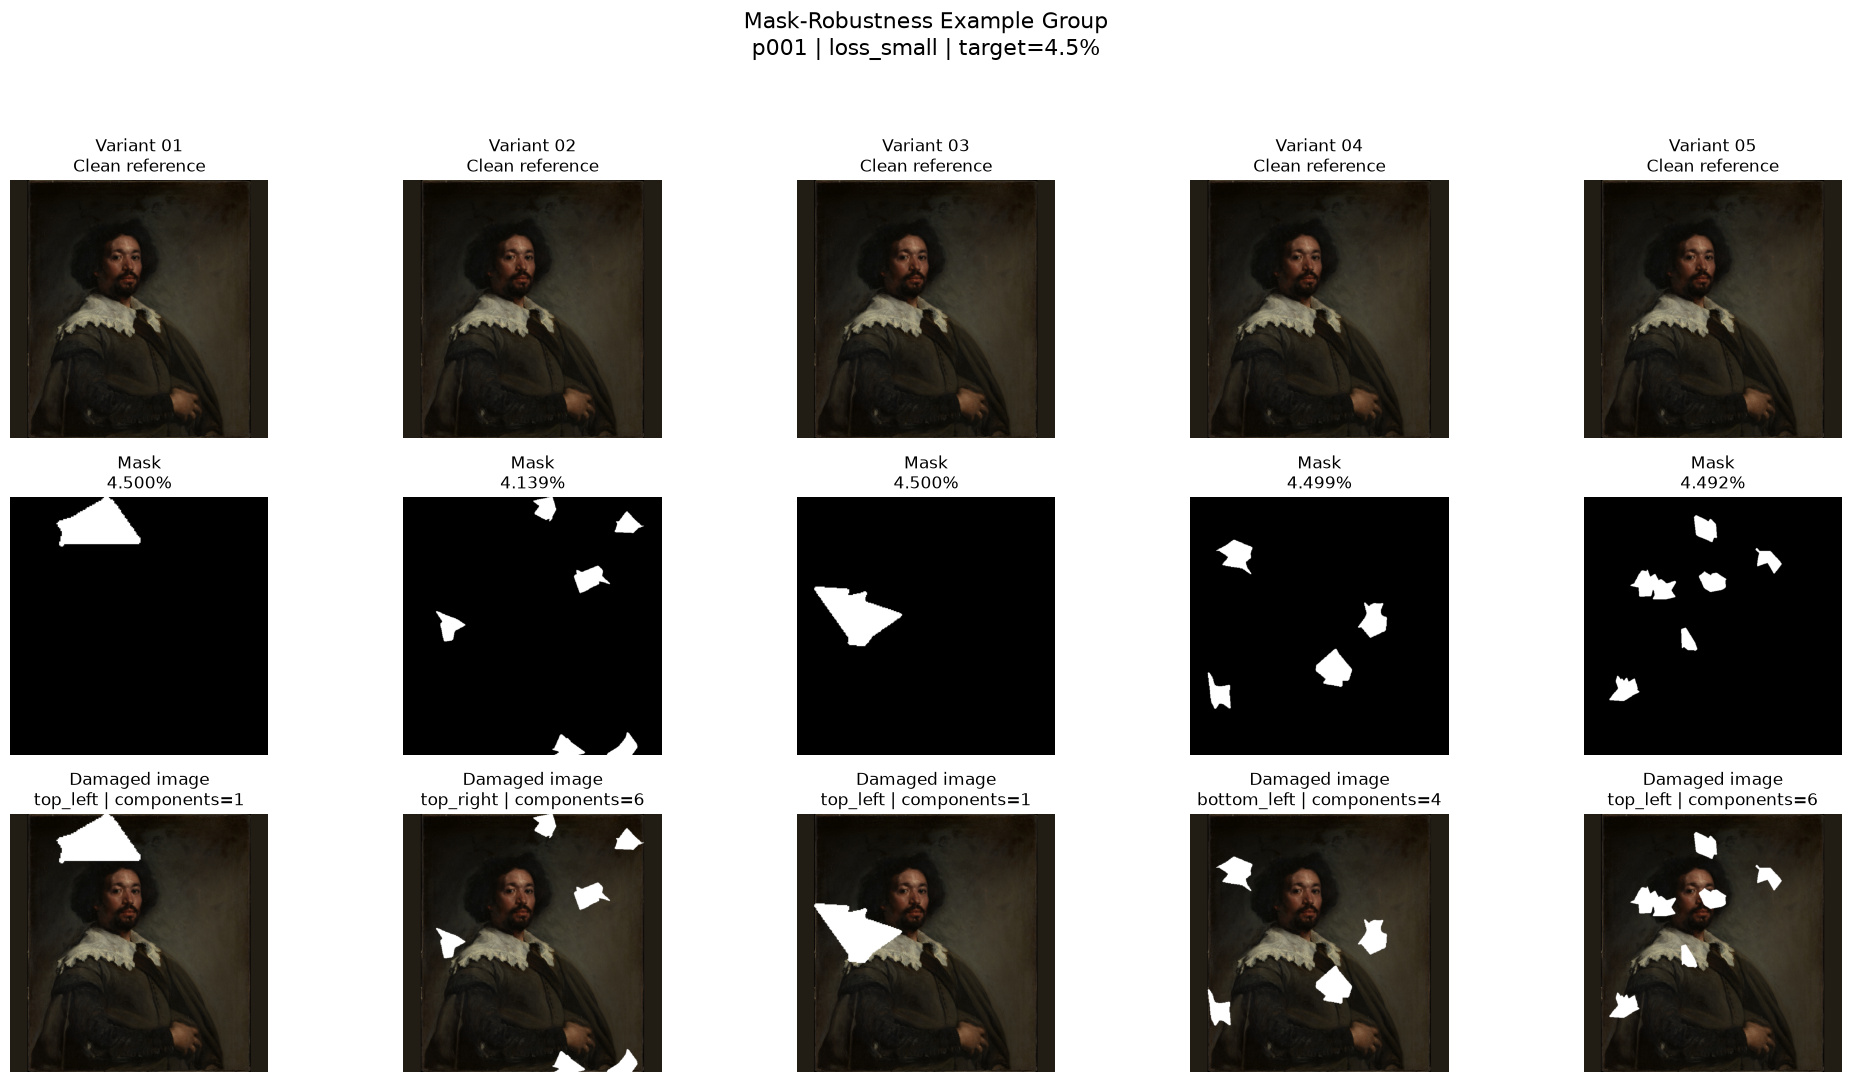

Example robustness grid saved:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\mask_robustness\p001__loss_small__example_variant_grid.png


In [8]:
# Visualise the clean image, five masks, and five damaged variants

example_rows_df = (
    example_robustness_metadata_df
    .sort_values(
        "variant_index",
        kind="stable",
    )
    .reset_index(drop=True)
)


if (
    len(
        example_rows_df
    )
    != variants_per_mask_type
):
    raise ValueError(
        "Example grid requires exactly "
        f"{variants_per_mask_type} variants."
    )


example_clean_path = Path(
    str(
        example_rows_df[
            "clean_path"
        ]
        .iloc[0]
    )
)


if not example_clean_path.is_absolute():
    example_clean_path = (
        PROJECT_ROOT
        / example_clean_path
    )


if not example_clean_path.exists():
    raise FileNotFoundError(
        "Example clean image does not exist: "
        f"{example_clean_path}"
    )


with Image.open(
    example_clean_path
) as clean_image:
    example_clean_rgb = (
        clean_image
        .convert("RGB")
        .copy()
    )


figure, axes = plt.subplots(
    nrows=3,
    ncols=variants_per_mask_type,
    figsize=(
        4 * variants_per_mask_type,
        11,
    ),
    squeeze=False,
)


for column_index, case_row in (
    example_rows_df.iterrows()
):
    mask_path = Path(
        str(
            case_row[
                "mask_path"
            ]
        )
    )

    damaged_path = Path(
        str(
            case_row[
                "damaged_path"
            ]
        )
    )


    if not mask_path.is_absolute():
        mask_path = (
            PROJECT_ROOT
            / mask_path
        )


    if not damaged_path.is_absolute():
        damaged_path = (
            PROJECT_ROOT
            / damaged_path
        )


    if not mask_path.exists():
        raise FileNotFoundError(
            "Example mask does not exist: "
            f"{mask_path}"
        )


    if not damaged_path.exists():
        raise FileNotFoundError(
            "Example damaged image does not exist: "
            f"{damaged_path}"
        )


    with Image.open(
        mask_path
    ) as mask_image:
        mask_display = (
            mask_image
            .convert("L")
            .copy()
        )


    with Image.open(
        damaged_path
    ) as damaged_image:
        damaged_display = (
            damaged_image
            .convert("RGB")
            .copy()
        )


    variant_index = int(
        case_row[
            "variant_index"
        ]
    )

    realised_percentage = float(
        case_row[
            "realised_percentage_content"
        ]
    )

    centroid_quadrant = str(
        case_row.get(
            "centroid_quadrant",
            "unknown",
        )
    )

    component_count = case_row.get(
        "connected_component_count",
        np.nan,
    )


    axes[
        0,
        column_index,
    ].imshow(
        example_clean_rgb
    )

    axes[
        0,
        column_index,
    ].set_title(
        (
            f"Variant {variant_index:02d}\n"
            "Clean reference"
        )
    )


    axes[
        1,
        column_index,
    ].imshow(
        mask_display,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        1,
        column_index,
    ].set_title(
        (
            f"Mask\n"
            f"{realised_percentage:.3f}%"
        )
    )


    axes[
        2,
        column_index,
    ].imshow(
        damaged_display
    )

    axes[
        2,
        column_index,
    ].set_title(
        (
            f"Damaged image\n"
            f"{centroid_quadrant} | "
            f"components={component_count}"
        )
    )


    for row_index in range(3):
        axes[
            row_index,
            column_index,
        ].axis(
            "off"
        )


figure.suptitle(
    (
        "Mask-Robustness Example Group\n"
        f"{example_painting_id} | "
        f"{example_mask_type} | "
        f"target="
        f"{target_percentages[example_mask_type]:.1f}%"
    ),
    fontsize=16,
)


figure.tight_layout(
    rect=[
        0.0,
        0.0,
        1.0,
        0.94,
    ]
)


example_grid_path = (
    robustness_figure_dir
    / (
        f"{example_painting_id}"
        f"__{example_mask_type}"
        f"__example_variant_grid.png"
    )
)


figure.savefig(
    example_grid_path,
    dpi=180,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)


if not example_grid_path.exists():
    raise RuntimeError(
        "Example robustness grid was not created."
    )


if (
    example_grid_path.stat().st_size
    <= 0
):
    raise RuntimeError(
        "Example robustness grid is empty."
    )


print(
    "Example robustness grid saved:"
)

print(
    example_grid_path
)

In [9]:
# Remove temporary example artifacts before full generation

if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )


if temporary_test_dir.exists():
    raise RuntimeError(
        "Temporary test directory could not be removed."
    )


print(
    "Temporary example artifacts removed."
)

Temporary example artifacts removed.


In [10]:
# Generate the complete canonical mask-robustness dataset

# Remove stale canonical files before regeneration.
# This prevents old or renamed outputs from surviving unnoticed.

for output_directory in [
    robustness_mask_dir,
    robustness_damaged_dir,
]:
    for existing_path in output_directory.iterdir():
        if existing_path.is_file():
            existing_path.unlink()


full_generation_started_at_utc = (
    datetime.now(
        timezone.utc
    )
)


robustness_metadata_df = (
    create_mask_robustness_dataset(
        processed_metadata=(
            robustness_processed_metadata_df
        ),
        output_mask_dir=(
            robustness_mask_dir
        ),
        output_damaged_dir=(
            robustness_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        mask_types=base_mask_types,
        target_percentages=(
            target_percentages
        ),
        variants_per_mask_type=(
            variants_per_mask_type
        ),
        target_size=target_size,
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)


full_generation_finished_at_utc = (
    datetime.now(
        timezone.utc
    )
)


full_generation_duration_seconds = (
    full_generation_finished_at_utc
    - full_generation_started_at_utc
).total_seconds()


required_generated_columns = [
    "case_id",
    "variant_id",
    "robustness_group_id",
    "painting_id",
    "base_mask_type",
    "variant_index",
    "variant_seed",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "mask_path",
    "damaged_path",
    "mask_sha256",
    "damaged_sha256",
    "generator_name",
    "generator_version",
    "status",
]


missing_generated_columns = [
    column_name
    for column_name
    in required_generated_columns
    if column_name
    not in robustness_metadata_df.columns
]


if missing_generated_columns:
    raise ValueError(
        "Generated robustness metadata is missing "
        "required columns: "
        f"{missing_generated_columns}"
    )


if (
    len(
        robustness_metadata_df
    )
    != expected_case_count
):
    raise ValueError(
        "Full generation produced the wrong "
        "number of cases: "
        f"observed={len(robustness_metadata_df)}, "
        f"expected={expected_case_count}"
    )


for identifier_column in [
    "case_id",
    "variant_id",
    "robustness_group_id",
    "painting_id",
    "base_mask_type",
]:
    robustness_metadata_df[
        identifier_column
    ] = (
        robustness_metadata_df[
            identifier_column
        ]
        .astype(str)
    )


duplicate_case_rows_df = (
    robustness_metadata_df.loc[
        robustness_metadata_df[
            "case_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_case_rows_df.empty:
    display(
        duplicate_case_rows_df
    )

    raise ValueError(
        "Generated metadata contains duplicate "
        "case IDs."
    )


observed_case_ids = set(
    robustness_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


missing_generated_case_ids = sorted(
    expected_case_ids
    - observed_case_ids
)


unexpected_generated_case_ids = sorted(
    observed_case_ids
    - expected_case_ids
)


if missing_generated_case_ids:
    display(
        pd.DataFrame(
            {
                "missing_case_id": (
                    missing_generated_case_ids
                )
            }
        )
    )


if unexpected_generated_case_ids:
    display(
        pd.DataFrame(
            {
                "unexpected_case_id": (
                    unexpected_generated_case_ids
                )
            }
        )
    )


if (
    missing_generated_case_ids
    or unexpected_generated_case_ids
):
    raise ValueError(
        "Generated case inventory does not match "
        "the expected 75-case design."
    )


invalid_status_rows_df = (
    robustness_metadata_df.loc[
        robustness_metadata_df[
            "status"
        ]
        .astype(str)
        .ne("ok")
    ]
    .copy()
)


if not invalid_status_rows_df.empty:
    display(
        invalid_status_rows_df
    )

    raise ValueError(
        "One or more robustness cases were not "
        "generated successfully."
    )


observed_painting_count = int(
    robustness_metadata_df[
        "painting_id"
    ]
    .nunique()
)


observed_mask_family_count = int(
    robustness_metadata_df[
        "base_mask_type"
    ]
    .nunique()
)


observed_group_count = int(
    robustness_metadata_df[
        "robustness_group_id"
    ]
    .nunique()
)


observed_variant_seed_count = int(
    robustness_metadata_df[
        "variant_seed"
    ]
    .nunique()
)


observed_mask_checksum_count = int(
    robustness_metadata_df[
        "mask_sha256"
    ]
    .nunique()
)


observed_damaged_checksum_count = int(
    robustness_metadata_df[
        "damaged_sha256"
    ]
    .nunique()
)


observed_generator_names = sorted(
    robustness_metadata_df[
        "generator_name"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


observed_generator_versions = sorted(
    robustness_metadata_df[
        "generator_version"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


group_generation_summary_df = (
    robustness_metadata_df
    .groupby(
        [
            "painting_id",
            "base_mask_type",
            "robustness_group_id",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        variant_count=(
            "variant_index",
            "nunique",
        ),
        seed_count=(
            "variant_seed",
            "nunique",
        ),
        mask_checksum_count=(
            "mask_sha256",
            "nunique",
        ),
        damaged_checksum_count=(
            "damaged_sha256",
            "nunique",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
        mean_realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        maximum_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)


invalid_generated_groups_df = (
    group_generation_summary_df.loc[
        (
            group_generation_summary_df[
                "case_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            group_generation_summary_df[
                "variant_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            group_generation_summary_df[
                "seed_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            group_generation_summary_df[
                "mask_checksum_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            group_generation_summary_df[
                "damaged_checksum_count"
            ]
            != variants_per_mask_type
        )
    ]
    .copy()
)


family_generation_summary_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        group_count=(
            "robustness_group_id",
            "nunique",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
        minimum_realised_percentage_content=(
            "realised_percentage_content",
            "min",
        ),
        mean_realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        maximum_realised_percentage_content=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)


generation_summary_df = pd.DataFrame(
    [
        {
            "check": "generated_cases",
            "observed": len(
                robustness_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    robustness_metadata_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "unique_paintings",
            "observed": observed_painting_count,
            "expected": expected_painting_count,
            "passed": (
                observed_painting_count
                == expected_painting_count
            ),
        },
        {
            "check": "mask_families",
            "observed": observed_mask_family_count,
            "expected": expected_mask_type_count,
            "passed": (
                observed_mask_family_count
                == expected_mask_type_count
            ),
        },
        {
            "check": "robustness_groups",
            "observed": observed_group_count,
            "expected": expected_group_count,
            "passed": (
                observed_group_count
                == expected_group_count
            ),
        },
        {
            "check": "unique_variant_seeds",
            "observed": observed_variant_seed_count,
            "expected": expected_case_count,
            "passed": (
                observed_variant_seed_count
                == expected_case_count
            ),
        },
        {
            "check": "unique_mask_checksums",
            "observed": observed_mask_checksum_count,
            "expected": expected_case_count,
            "passed": (
                observed_mask_checksum_count
                == expected_case_count
            ),
        },
        {
            "check": "unique_damaged_checksums",
            "observed": observed_damaged_checksum_count,
            "expected": expected_case_count,
            "passed": (
                observed_damaged_checksum_count
                == expected_case_count
            ),
        },
        {
            "check": "generator_name",
            "observed": str(
                observed_generator_names
            ),
            "expected": str(
                [GENERATOR_NAME]
            ),
            "passed": (
                observed_generator_names
                == [GENERATOR_NAME]
            ),
        },
        {
            "check": "generator_version",
            "observed": str(
                observed_generator_versions
            ),
            "expected": str(
                [GENERATOR_VERSION]
            ),
            "passed": (
                observed_generator_versions
                == [GENERATOR_VERSION]
            ),
        },
        {
            "check": "invalid_robustness_groups",
            "observed": len(
                invalid_generated_groups_df
            ),
            "expected": 0,
            "passed": (
                invalid_generated_groups_df.empty
            ),
        },
        {
            "check": "generation_duration_seconds",
            "observed": round(
                full_generation_duration_seconds,
                3,
            ),
            "expected": ">= 0",
            "passed": (
                full_generation_duration_seconds
                >= 0
            ),
        },
    ]
)


print("Full mask-robustness generation summary")
print("---------------------------------------")

display(
    generation_summary_df
)


print("\nMask-family generation summary")
print("------------------------------")

display(
    family_generation_summary_df
)


print("\nRobustness-group generation summary")
print("-----------------------------------")

display(
    group_generation_summary_df
)


failed_generation_summary_df = (
    generation_summary_df.loc[
        ~generation_summary_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not invalid_generated_groups_df.empty:
    print("\nInvalid generated groups")

    display(
        invalid_generated_groups_df
    )


if not failed_generation_summary_df.empty:
    display(
        failed_generation_summary_df
    )

    raise ValueError(
        "Full mask-robustness generation gate failed."
    )


print(
    "\nFull 75-case mask-robustness generation completed."
)

Full mask-robustness generation summary
---------------------------------------


,check,observed,expected,passed
0,generated_cases,75,75,True
1,unique_paintings,5,5,True
2,mask_families,3,3,True
3,robustness_groups,15,15,True
4,unique_variant_seeds,75,75,True
5,unique_mask_checksums,75,75,True
6,unique_damaged_checksums,75,75,True
7,generator_name,['mask_robustness'],['mask_robustness'],True
8,generator_version,['1.1.0'],['1.1.0'],True
9,invalid_robustness_groups,0,0,True



Mask-family generation summary
------------------------------


,base_mask_type,case_count,painting_count,group_count,target_percentage_content,minimum_realised_percentage_content,mean_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error,maximum_absolute_percentage_error
0,loss_large,25,5,5,12.5,12.480309,12.503526,12.525786,0.011011,0.025786
1,loss_small,25,5,5,4.5,4.336154,4.491647,4.510293,0.011279,0.163846
2,scratch_thin,25,5,5,2.0,1.695851,1.976878,2.030167,0.032122,0.304149



Robustness-group generation summary
-----------------------------------


,painting_id,base_mask_type,robustness_group_id,case_count,variant_count,seed_count,mask_checksum_count,damaged_checksum_count,target_percentage_content,mean_realised_percentage_content,maximum_absolute_percentage_error
0,p001,loss_large,p001__loss_large,5,5,5,5,5,12.5,12.505263,0.019246
1,p001,loss_small,p001__loss_small,5,5,5,5,5,4.5,4.467658,0.163846
2,p001,scratch_thin,p001__scratch_thin,5,5,5,5,5,2.0,1.937256,0.304149
3,p018,loss_large,p018__loss_large,5,5,5,5,5,12.5,12.498870,0.009759
4,p018,loss_small,p018__loss_small,5,5,5,5,5,4.5,4.499353,0.010293
5,p018,scratch_thin,p018__scratch_thin,5,5,5,5,5,2.0,2.007109,0.027346
6,p026,loss_large,p026__loss_large,5,5,5,5,5,12.5,12.503052,0.021414
7,p026,loss_small,p026__loss_small,5,5,5,5,5,4.5,4.492360,0.011628
8,p026,scratch_thin,p026__scratch_thin,5,5,5,5,5,2.0,1.986551,0.105210
9,p039,loss_large,p039__loss_large,5,5,5,5,5,12.5,12.512744,0.025164



Full 75-case mask-robustness generation completed.


In [11]:
# Finalize, save, and reload the canonical mask-robustness metadata

robustness_metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


robustness_metadata_to_save_df = (
    robustness_metadata_df
    .copy()
)


robustness_metadata_to_save_df[
    "config_version"
] = config_version


robustness_metadata_to_save_df[
    "experiment_name"
] = experiment_name


robustness_metadata_to_save_df[
    "experiment_version"
] = experiment_version


robustness_metadata_to_save_df[
    "notebook_stage"
] = "06_mask_robustness"


robustness_metadata_to_save_df[
    "full_generation_started_at_utc"
] = (
    full_generation_started_at_utc.isoformat()
)


robustness_metadata_to_save_df[
    "full_generation_finished_at_utc"
] = (
    full_generation_finished_at_utc.isoformat()
)


robustness_metadata_to_save_df[
    "full_generation_duration_seconds"
] = float(
    full_generation_duration_seconds
)


robustness_metadata_to_save_df = (
    robustness_metadata_to_save_df
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "variant_index",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


required_canonical_metadata_columns = [
    "case_id",
    "variant_id",
    "robustness_group_id",
    "painting_id",
    "base_mask_type",
    "variant_index",
    "variant_seed",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "mask_path",
    "damaged_path",
    "mask_sha256",
    "damaged_sha256",
    "generator_name",
    "generator_version",
    "status",
    "config_version",
    "experiment_name",
    "experiment_version",
    "notebook_stage",
]


missing_canonical_metadata_columns = [
    column_name
    for column_name
    in required_canonical_metadata_columns
    if column_name
    not in robustness_metadata_to_save_df.columns
]


if missing_canonical_metadata_columns:
    raise RuntimeError(
        "Canonical robustness metadata is missing "
        "required columns: "
        f"{missing_canonical_metadata_columns}"
    )


if (
    len(
        robustness_metadata_to_save_df
    )
    != expected_case_count
):
    raise RuntimeError(
        "Canonical robustness metadata row count "
        "is invalid: "
        f"observed={len(robustness_metadata_to_save_df)}, "
        f"expected={expected_case_count}"
    )


duplicate_canonical_case_rows_df = (
    robustness_metadata_to_save_df.loc[
        robustness_metadata_to_save_df[
            "case_id"
        ]
        .astype(str)
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_canonical_case_rows_df.empty:
    display(
        duplicate_canonical_case_rows_df
    )

    raise RuntimeError(
        "Canonical robustness metadata contains "
        "duplicate case IDs."
    )


required_value_audit_df = (
    robustness_metadata_to_save_df[
        required_canonical_metadata_columns
    ]
    .isna()
    .sum()
    .rename(
        "missing_count"
    )
    .reset_index()
    .rename(
        columns={
            "index": "column",
        }
    )
)


display(
    required_value_audit_df
)


if (
    required_value_audit_df[
        "missing_count"
    ]
    > 0
).any():
    raise RuntimeError(
        "Canonical robustness metadata contains "
        "missing required values."
    )


if not (
    robustness_metadata_to_save_df[
        "status"
    ]
    .astype(str)
    .eq("ok")
    .all()
):
    invalid_status_rows_df = (
        robustness_metadata_to_save_df.loc[
            robustness_metadata_to_save_df[
                "status"
            ]
            .astype(str)
            .ne("ok")
        ]
        .copy()
    )


    display(
        invalid_status_rows_df
    )


    raise RuntimeError(
        "Canonical robustness metadata contains "
        "unsuccessful generation rows."
    )


temporary_robustness_metadata_path = (
    robustness_metadata_path.with_suffix(
        ".tmp.csv"
    )
)


robustness_metadata_to_save_df.to_csv(
    temporary_robustness_metadata_path,
    index=False,
)


temporary_robustness_metadata_path.replace(
    robustness_metadata_path
)


if not robustness_metadata_path.exists():
    raise RuntimeError(
        "Canonical robustness metadata was not saved."
    )


if (
    robustness_metadata_path.stat().st_size
    <= 0
):
    raise RuntimeError(
        "Canonical robustness metadata file is empty."
    )


reloaded_robustness_metadata_df = pd.read_csv(
    robustness_metadata_path
)


if (
    len(
        reloaded_robustness_metadata_df
    )
    != expected_case_count
):
    raise RuntimeError(
        "Reloaded robustness metadata row count "
        "is invalid."
    )


if list(
    reloaded_robustness_metadata_df.columns
) != list(
    robustness_metadata_to_save_df.columns
):
    raise RuntimeError(
        "Reloaded robustness metadata columns "
        "do not match the saved dataframe."
    )


string_comparison_columns = [
    column_name
    for column_name in [
        "case_id",
        "variant_id",
        "robustness_group_id",
        "painting_id",
        "base_mask_type",
        "mask_path",
        "damaged_path",
        "mask_sha256",
        "damaged_sha256",
        "generator_name",
        "generator_version",
        "status",
        "config_version",
        "experiment_name",
        "experiment_version",
        "notebook_stage",
    ]
    if column_name
    in robustness_metadata_to_save_df.columns
]


for column_name in string_comparison_columns:
    original_values = (
        robustness_metadata_to_save_df[
            column_name
        ]
        .fillna("")
        .astype(str)
        .tolist()
    )

    reloaded_values = (
        reloaded_robustness_metadata_df[
            column_name
        ]
        .fillna("")
        .astype(str)
        .tolist()
    )

    if original_values != reloaded_values:
        raise RuntimeError(
            "Reload verification failed for "
            f"string column: {column_name}"
        )


numeric_comparison_columns = [
    column_name
    for column_name in [
        "variant_index",
        "variant_seed",
        "target_percentage_content",
        "realised_percentage_content",
        "absolute_percentage_error_content",
        "connected_component_count",
        "largest_component_fraction",
        "bbox_fill_ratio",
        "bbox_aspect_ratio",
        "perimeter_pixels",
        "perimeter_to_area_ratio",
        "centroid_x_normalised_content",
        "centroid_y_normalised_content",
        "mask_bbox_width_normalised_content",
        "mask_bbox_height_normalised_content",
        "mask_bbox_area_fraction_content",
        "distance_to_nearest_content_border_normalised",
        "full_generation_duration_seconds",
    ]
    if column_name
    in robustness_metadata_to_save_df.columns
]


for column_name in numeric_comparison_columns:
    original_values = pd.to_numeric(
        robustness_metadata_to_save_df[
            column_name
        ],
        errors="coerce",
    ).to_numpy()

    reloaded_values = pd.to_numeric(
        reloaded_robustness_metadata_df[
            column_name
        ],
        errors="coerce",
    ).to_numpy()

    if not np.allclose(
        original_values,
        reloaded_values,
        equal_nan=True,
    ):
        raise RuntimeError(
            "Reload verification failed for "
            f"numeric column: {column_name}"
        )


robustness_metadata_df = (
    reloaded_robustness_metadata_df
    .copy()
)


canonical_metadata_save_audit_df = pd.DataFrame(
    [
        {
            "check": "metadata_file_exists",
            "observed": int(
                robustness_metadata_path.exists()
            ),
            "expected": 1,
            "passed": (
                robustness_metadata_path.exists()
            ),
        },
        {
            "check": "metadata_file_nonempty",
            "observed": (
                robustness_metadata_path.stat().st_size
                if robustness_metadata_path.exists()
                else 0
            ),
            "expected": "> 0",
            "passed": (
                robustness_metadata_path.exists()
                and robustness_metadata_path.stat().st_size
                > 0
            ),
        },
        {
            "check": "metadata_rows",
            "observed": len(
                robustness_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    robustness_metadata_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                robustness_metadata_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
            ),
            "expected": expected_case_count,
            "passed": (
                robustness_metadata_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
                == expected_case_count
            ),
        },
        {
            "check": "all_status_ok",
            "observed": int(
                robustness_metadata_df[
                    "status"
                ]
                .astype(str)
                .ne("ok")
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                robustness_metadata_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .all()
            ),
        },
    ]
)


display(
    canonical_metadata_save_audit_df
)


if not canonical_metadata_save_audit_df[
    "passed"
].astype(bool).all():
    raise RuntimeError(
        "Canonical robustness metadata save "
        "or reload validation failed."
    )


print(
    "\nCanonical mask-robustness metadata "
    "saved and reloaded successfully:"
)

print(
    robustness_metadata_path
)

,column,missing_count
0,case_id,0
1,variant_id,0
2,robustness_group_id,0
3,painting_id,0
4,base_mask_type,0
5,variant_index,0
6,variant_seed,0
7,target_percentage_content,0
8,realised_percentage_content,0
9,absolute_percentage_error_content,0


,check,observed,expected,passed
0,metadata_file_exists,1,1,True
1,metadata_file_nonempty,111902,> 0,True
2,metadata_rows,75,75,True
3,unique_case_ids,75,75,True
4,all_status_ok,0,0,True



Canonical mask-robustness metadata saved and reloaded successfully:
D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_mask_robustness.csv


In [12]:
# Audit metadata and the complete generated-file inventory

inventory_audit = audit_mask_robustness_inventory(
    robustness_metadata=robustness_metadata_df,
    mask_dir=robustness_mask_dir,
    damaged_dir=robustness_damaged_dir,
    expected_case_ids=(
        expected_case_manifest_df[
            "case_id"
        ]
        .astype(str)
        .tolist()
    ),
    project_root=PROJECT_ROOT,
)


if not isinstance(
    inventory_audit,
    dict,
):
    raise TypeError(
        "Inventory audit must return a dictionary "
        "of audit dataframes."
    )


if "summary" not in inventory_audit:
    raise KeyError(
        "Inventory audit did not return a "
        "'summary' dataframe."
    )


inventory_summary_df = (
    inventory_audit[
        "summary"
    ]
    .copy()
)


required_inventory_summary_columns = [
    "check",
    "passed",
]


missing_inventory_summary_columns = [
    column_name
    for column_name
    in required_inventory_summary_columns
    if column_name
    not in inventory_summary_df.columns
]


if missing_inventory_summary_columns:
    raise ValueError(
        "Inventory summary is missing required columns: "
        f"{missing_inventory_summary_columns}"
    )


inventory_summary_df[
    "passed"
] = (
    inventory_summary_df[
        "passed"
    ]
    .astype(bool)
)


failed_inventory_checks_df = (
    inventory_summary_df.loc[
        ~inventory_summary_df[
            "passed"
        ]
    ]
    .copy()
)


print("Mask-robustness inventory audit")
print("--------------------------------")

display(
    inventory_summary_df
)


if not failed_inventory_checks_df.empty:
    print("\nFailed inventory summary checks")

    display(
        failed_inventory_checks_df
    )

    for audit_name, audit_df in (
        inventory_audit.items()
    ):
        if (
            audit_name != "summary"
            and isinstance(
                audit_df,
                pd.DataFrame,
            )
            and not audit_df.empty
        ):
            print(
                f"\nInventory detail: {audit_name}"
            )

            display(
                audit_df
            )

    raise RuntimeError(
        "Mask-robustness inventory audit failed."
    )


# ---------------------------------------------------------------------
# Additional canonical file checks
# ---------------------------------------------------------------------

metadata_case_ids = set(
    robustness_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


mask_files = sorted(
    path
    for path in robustness_mask_dir.rglob(
        "*"
    )
    if path.is_file()
)


damaged_files = sorted(
    path
    for path in robustness_damaged_dir.rglob(
        "*"
    )
    if path.is_file()
)


mask_png_files = [
    path
    for path in mask_files
    if path.suffix.lower() == ".png"
]


damaged_png_files = [
    path
    for path in damaged_files
    if path.suffix.lower() == ".png"
]


non_png_mask_files = [
    path
    for path in mask_files
    if path.suffix.lower() != ".png"
]


non_png_damaged_files = [
    path
    for path in damaged_files
    if path.suffix.lower() != ".png"
]


zero_byte_mask_files = [
    path
    for path in mask_files
    if path.stat().st_size <= 0
]


zero_byte_damaged_files = [
    path
    for path in damaged_files
    if path.stat().st_size <= 0
]


checksum_columns = [
    column_name
    for column_name in [
        "mask_sha256",
        "damaged_sha256",
    ]
    if column_name
    in robustness_metadata_df.columns
]


invalid_checksum_length_count = 0


for checksum_column in checksum_columns:
    checksum_series = (
        robustness_metadata_df[
            checksum_column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    non_empty_checksum_series = (
        checksum_series.loc[
            checksum_series.ne("")
        ]
    )

    invalid_checksum_length_count += int(
        non_empty_checksum_series
        .str.len()
        .ne(64)
        .sum()
    )


canonical_inventory_checks_df = pd.DataFrame(
    [
        {
            "audit_section": "canonical_inventory",
            "check": "metadata_case_count",
            "observed": len(
                robustness_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    robustness_metadata_df
                )
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "canonical_inventory",
            "check": "metadata_case_ids_match_design",
            "observed": len(
                metadata_case_ids
                & expected_case_ids
            ),
            "expected": expected_case_count,
            "passed": (
                metadata_case_ids
                == expected_case_ids
            ),
            "details": "",
        },
        {
            "audit_section": "canonical_inventory",
            "check": "mask_png_count",
            "observed": len(
                mask_png_files
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    mask_png_files
                )
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "canonical_inventory",
            "check": "damaged_png_count",
            "observed": len(
                damaged_png_files
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    damaged_png_files
                )
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "canonical_inventory",
            "check": "non_png_mask_files",
            "observed": len(
                non_png_mask_files
            ),
            "expected": 0,
            "passed": (
                not non_png_mask_files
            ),
            "details": "; ".join(
                str(path)
                for path in non_png_mask_files
            ),
        },
        {
            "audit_section": "canonical_inventory",
            "check": "non_png_damaged_files",
            "observed": len(
                non_png_damaged_files
            ),
            "expected": 0,
            "passed": (
                not non_png_damaged_files
            ),
            "details": "; ".join(
                str(path)
                for path in non_png_damaged_files
            ),
        },
        {
            "audit_section": "canonical_inventory",
            "check": "zero_byte_mask_files",
            "observed": len(
                zero_byte_mask_files
            ),
            "expected": 0,
            "passed": (
                not zero_byte_mask_files
            ),
            "details": "; ".join(
                str(path)
                for path in zero_byte_mask_files
            ),
        },
        {
            "audit_section": "canonical_inventory",
            "check": "zero_byte_damaged_files",
            "observed": len(
                zero_byte_damaged_files
            ),
            "expected": 0,
            "passed": (
                not zero_byte_damaged_files
            ),
            "details": "; ".join(
                str(path)
                for path in zero_byte_damaged_files
            ),
        },
        {
            "audit_section": "canonical_inventory",
            "check": "invalid_checksum_lengths",
            "observed": (
                invalid_checksum_length_count
            ),
            "expected": 0,
            "passed": (
                invalid_checksum_length_count
                == 0
            ),
            "details": "",
        },
    ]
)


normalised_inventory_summary_df = (
    inventory_summary_df
    .copy()
)


normalised_inventory_summary_df[
    "audit_section"
] = "module_inventory"


if "observed" not in (
    normalised_inventory_summary_df.columns
):
    normalised_inventory_summary_df[
        "observed"
    ] = ""


if "expected" not in (
    normalised_inventory_summary_df.columns
):
    normalised_inventory_summary_df[
        "expected"
    ] = ""


if "details" not in (
    normalised_inventory_summary_df.columns
):
    normalised_inventory_summary_df[
        "details"
    ] = ""


normalised_inventory_summary_df = (
    normalised_inventory_summary_df[
        [
            "audit_section",
            "check",
            "observed",
            "expected",
            "passed",
            "details",
        ]
    ]
)


mask_robustness_audit_df = pd.concat(
    [
        normalised_inventory_summary_df,
        canonical_inventory_checks_df,
    ],
    ignore_index=True,
)


mask_robustness_audit_df[
    "passed"
] = (
    mask_robustness_audit_df[
        "passed"
    ]
    .astype(bool)
)


robustness_audit_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


mask_robustness_audit_df.to_csv(
    robustness_audit_path,
    index=False,
)


if not robustness_audit_path.exists():
    raise RuntimeError(
        "Canonical audit CSV was not created."
    )


if robustness_audit_path.stat().st_size <= 0:
    raise RuntimeError(
        "Canonical audit CSV is empty."
    )


failed_canonical_inventory_checks_df = (
    canonical_inventory_checks_df.loc[
        ~canonical_inventory_checks_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


print("\nCanonical inventory checks")
print("--------------------------")

display(
    canonical_inventory_checks_df
)


if not failed_canonical_inventory_checks_df.empty:
    display(
        failed_canonical_inventory_checks_df
    )

    raise RuntimeError(
        "Canonical mask-robustness inventory "
        "checks failed."
    )


print(
    "\nMask-robustness inventory audit passed."
)

print(
    "Canonical audit:",
    robustness_audit_path,
)

Mask-robustness inventory audit
--------------------------------


,check,issue_count,passed
0,duplicate_case_ids,0,True
1,duplicate_mask_paths,0,True
2,duplicate_damaged_paths,0,True
3,missing_expected_cases,0,True
4,unexpected_metadata_cases,0,True
5,missing_mask_files,0,True
6,missing_damaged_files,0,True
7,orphan_mask_files,0,True
8,orphan_damaged_files,0,True



Canonical inventory checks
--------------------------


,audit_section,check,observed,expected,passed,details
0,canonical_inventory,metadata_case_count,75,75,True,
1,canonical_inventory,metadata_case_ids_match_design,75,75,True,
2,canonical_inventory,mask_png_count,75,75,True,
3,canonical_inventory,damaged_png_count,75,75,True,
4,canonical_inventory,non_png_mask_files,0,0,True,
5,canonical_inventory,non_png_damaged_files,0,0,True,
6,canonical_inventory,zero_byte_mask_files,0,0,True,
7,canonical_inventory,zero_byte_damaged_files,0,0,True,
8,canonical_inventory,invalid_checksum_lengths,0,0,True,



Mask-robustness inventory audit passed.
Canonical audit: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\06_mask_robustness\mask_robustness_audit.csv


In [13]:
# Summarise target-area accuracy and deterministic retry behaviour.
# These dataframes remain in memory and are not written as separate CSVs.

generation_seed_column = next(
    (
        column_name
        for column_name in [
            "variant_seed",
            "generation_seed",
        ]
        if column_name
        in robustness_metadata_df.columns
    ),
    None,
)


if generation_seed_column is None:
    raise ValueError(
        "Robustness metadata does not contain "
        "a deterministic generation-seed column."
    )


generation_attempt_column = next(
    (
        column_name
        for column_name in [
            "generation_attempt_index",
            "attempt_index",
        ]
        if column_name
        in robustness_metadata_df.columns
    ),
    None,
)


maximum_attempt_column = next(
    (
        column_name
        for column_name in [
            "maximum_generation_attempts",
            "maximum_attempts",
        ]
        if column_name
        in robustness_metadata_df.columns
    ),
    None,
)


area_summary_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        group_count=(
            "robustness_group_id",
            "nunique",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
        minimum_realised_percentage=(
            "realised_percentage_content",
            "min",
        ),
        mean_realised_percentage=(
            "realised_percentage_content",
            "mean",
        ),
        maximum_realised_percentage=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)


if generation_attempt_column is not None:
    retry_summary_df = (
        robustness_metadata_df
        .groupby(
            generation_attempt_column,
            sort=True,
        )
        .agg(
            case_count=(
                "case_id",
                "count",
            ),
            painting_count=(
                "painting_id",
                "nunique",
            ),
            mask_family_count=(
                "base_mask_type",
                "nunique",
            ),
        )
        .reset_index()
    )


    retried_cases_df = (
        robustness_metadata_df.loc[
            pd.to_numeric(
                robustness_metadata_df[
                    generation_attempt_column
                ],
                errors="coerce",
            )
            .gt(1)
        ]
        .copy()
        .sort_values(
            [
                generation_attempt_column,
                "case_id",
            ],
            ascending=[
                False,
                True,
            ],
            kind="stable",
        )
        .reset_index(drop=True)
    )


    maximum_generation_attempt_used = int(
        pd.to_numeric(
            robustness_metadata_df[
                generation_attempt_column
            ],
            errors="raise",
        )
        .max()
    )
else:
    retry_summary_df = pd.DataFrame(
        [
            {
                "generation_attempt_index": 1,
                "case_count": (
                    expected_case_count
                ),
                "painting_count": (
                    expected_painting_count
                ),
                "mask_family_count": (
                    expected_mask_type_count
                ),
            }
        ]
    )


    retried_cases_df = (
        robustness_metadata_df.iloc[
            0:0
        ]
        .copy()
    )


    maximum_generation_attempt_used = 1


area_tolerance_passed = bool(
    pd.to_numeric(
        robustness_metadata_df[
            "absolute_percentage_error_content"
        ],
        errors="raise",
    )
    .le(
        maximum_percentage_error
    )
    .all()
)


unique_seed_count = int(
    robustness_metadata_df[
        generation_seed_column
    ]
    .nunique()
)


if (
    generation_attempt_column is not None
    and maximum_attempt_column is not None
):
    attempt_limit_respected = bool(
        pd.to_numeric(
            robustness_metadata_df[
                generation_attempt_column
            ],
            errors="raise",
        )
        .le(
            pd.to_numeric(
                robustness_metadata_df[
                    maximum_attempt_column
                ],
                errors="raise",
            )
        )
        .all()
    )


    configured_maximum_attempts = int(
        pd.to_numeric(
            robustness_metadata_df[
                maximum_attempt_column
            ],
            errors="raise",
        )
        .max()
    )
else:
    attempt_limit_respected = True
    configured_maximum_attempts = (
        maximum_generation_attempt_used
    )


retry_gate_df = pd.DataFrame(
    [
        {
            "check": (
                "all_cases_within_area_tolerance"
            ),
            "observed": int(
                pd.to_numeric(
                    robustness_metadata_df[
                        "absolute_percentage_error_content"
                    ],
                    errors="raise",
                )
                .le(
                    maximum_percentage_error
                )
                .sum()
            ),
            "expected": expected_case_count,
            "passed": area_tolerance_passed,
        },
        {
            "check": "unique_generation_seeds",
            "observed": unique_seed_count,
            "expected": expected_case_count,
            "passed": (
                unique_seed_count
                == expected_case_count
            ),
        },
        {
            "check": "attempt_limit_respected",
            "observed": (
                maximum_generation_attempt_used
            ),
            "expected": (
                f"<= {configured_maximum_attempts}"
            ),
            "passed": (
                attempt_limit_respected
            ),
        },
    ]
)


expected_family_case_count = (
    expected_painting_count
    * variants_per_mask_type
)


invalid_area_summary_df = (
    area_summary_df.loc[
        (
            area_summary_df[
                "case_count"
            ]
            != expected_family_case_count
        )
        |
        (
            area_summary_df[
                "painting_count"
            ]
            != expected_painting_count
        )
        |
        (
            area_summary_df[
                "group_count"
            ]
            != expected_painting_count
        )
        |
        (
            area_summary_df[
                "maximum_absolute_percentage_error"
            ]
            > maximum_percentage_error
        )
    ]
    .copy()
)


print("Area-control summary")
print("--------------------")

display(
    area_summary_df
)


print("\nGeneration-attempt distribution")
print("--------------------------------")

display(
    retry_summary_df
)


print("\nArea-control and retry gates")
print("----------------------------")

display(
    retry_gate_df
)


print(
    "\nCases requiring more than one attempt:",
    len(
        retried_cases_df
    ),
)


if not retried_cases_df.empty:
    retried_display_columns = [
        column_name
        for column_name in [
            "case_id",
            "painting_id",
            "base_mask_type",
            "variant_index",
            generation_attempt_column,
            "target_percentage_content",
            "realised_percentage_content",
            "absolute_percentage_error_content",
            "touches_content_border",
        ]
        if (
            column_name is not None
            and column_name
            in retried_cases_df.columns
        )
    ]


    display(
        retried_cases_df[
            retried_display_columns
        ]
    )


if not invalid_area_summary_df.empty:
    print("\nInvalid area-summary rows")

    display(
        invalid_area_summary_df
    )


failed_retry_gate_df = (
    retry_gate_df.loc[
        ~retry_gate_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_retry_gate_df.empty:
    display(
        failed_retry_gate_df
    )


if (
    not invalid_area_summary_df.empty
    or not failed_retry_gate_df.empty
):
    raise RuntimeError(
        "Area-control or deterministic retry "
        "checks failed."
    )


print(
    "\nArea-control and retry checks passed."
)

Area-control summary
--------------------


,base_mask_type,case_count,painting_count,group_count,target_percentage_content,minimum_realised_percentage,mean_realised_percentage,maximum_realised_percentage,mean_absolute_percentage_error,maximum_absolute_percentage_error
0,loss_large,25,5,5,12.5,12.480309,12.503526,12.525786,0.011011,0.025786
1,loss_small,25,5,5,4.5,4.336154,4.491647,4.510293,0.011279,0.163846
2,scratch_thin,25,5,5,2.0,1.695851,1.976878,2.030167,0.032122,0.304149



Generation-attempt distribution
--------------------------------


,generation_attempt_index,case_count,painting_count,mask_family_count
0,1,71,5,3
1,2,4,3,1



Area-control and retry gates
----------------------------


,check,observed,expected,passed
0,all_cases_within_area_tolerance,75,75,True
1,unique_generation_seeds,75,75,True
2,attempt_limit_respected,2,<= 20,True



Cases requiring more than one attempt: 4


,case_id,painting_id,base_mask_type,variant_index,generation_attempt_index,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,touches_content_border
0,p001__loss_small__variant_02,p001,loss_small,2,2,4.5,4.493464,0.006536,True
1,p001__loss_small__variant_05,p001,loss_small,5,2,4.5,4.497392,0.002608,True
2,p039__loss_small__variant_01,p039,loss_small,1,2,4.5,4.500499,0.000499,False
3,p043__loss_small__variant_01,p043,loss_small,1,2,4.5,4.495917,0.004083,True



Area-control and retry checks passed.


In [14]:
# Summarise mask morphology, location, and within-group distinctness.
# These summaries remain in memory.

morphology_candidate_columns = [
    "connected_component_count",
    "largest_component_fraction",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
    "perimeter_pixels",
    "perimeter_to_area_ratio",
    "centroid_x_normalised_content",
    "centroid_y_normalised_content",
    "mask_bbox_width_normalised_content",
    "mask_bbox_height_normalised_content",
    "mask_bbox_area_fraction_content",
    "mask_bbox_area_fraction_content_bbox",
    "distance_to_nearest_content_border_normalised",
]


morphology_summary_columns = [
    column_name
    for column_name
    in morphology_candidate_columns
    if column_name
    in robustness_metadata_df.columns
]


if not morphology_summary_columns:
    raise ValueError(
        "No morphology or location statistics "
        "are available in robustness metadata."
    )


morphology_summary_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )[
        morphology_summary_columns
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)


morphology_summary_df.columns = [
    f"{column_name}_{statistic_name}"
    for (
        column_name,
        statistic_name,
    )
    in morphology_summary_df.columns
]


morphology_summary_df = (
    morphology_summary_df
    .reset_index()
)


if (
    "centroid_quadrant"
    in robustness_metadata_df.columns
):
    quadrant_distribution_df = (
        robustness_metadata_df
        .groupby(
            [
                "base_mask_type",
                "centroid_quadrant",
            ],
            sort=False,
            dropna=False,
        )
        .agg(
            case_count=(
                "case_id",
                "count",
            ),
            painting_count=(
                "painting_id",
                "nunique",
            ),
        )
        .reset_index()
    )
else:
    quadrant_distribution_df = pd.DataFrame(
        columns=[
            "base_mask_type",
            "centroid_quadrant",
            "case_count",
            "painting_count",
        ]
    )


border_aggregation = {
    "case_count": (
        "case_id",
        "count",
    ),
}


border_column_mapping = {
    "touches_content_border": (
        "touches_content_border_count"
    ),
    "touches_left_content_border": (
        "touches_left_count"
    ),
    "touches_right_content_border": (
        "touches_right_count"
    ),
    "touches_top_content_border": (
        "touches_top_count"
    ),
    "touches_bottom_content_border": (
        "touches_bottom_count"
    ),
}


for (
    source_column,
    output_column,
) in border_column_mapping.items():
    if source_column in (
        robustness_metadata_df.columns
    ):
        border_aggregation[
            output_column
        ] = (
            source_column,
            "sum",
        )


border_distribution_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        **border_aggregation
    )
    .reset_index()
)


group_aggregation = {
    "case_count": (
        "case_id",
        "count",
    ),
    "variant_count": (
        "variant_index",
        "nunique",
    ),
    "unique_mask_count": (
        "mask_sha256",
        "nunique",
    ),
    "unique_damaged_count": (
        "damaged_sha256",
        "nunique",
    ),
    "unique_seed_count": (
        generation_seed_column,
        "nunique",
    ),
    "realised_percentage_std": (
        "realised_percentage_content",
        "std",
    ),
}


if (
    "centroid_x_normalised_content"
    in robustness_metadata_df.columns
):
    group_aggregation[
        "centroid_x_std"
    ] = (
        "centroid_x_normalised_content",
        "std",
    )


if (
    "centroid_y_normalised_content"
    in robustness_metadata_df.columns
):
    group_aggregation[
        "centroid_y_std"
    ] = (
        "centroid_y_normalised_content",
        "std",
    )


group_distinctness_df = (
    robustness_metadata_df
    .groupby(
        [
            "painting_id",
            "base_mask_type",
            "robustness_group_id",
        ],
        sort=True,
    )
    .agg(
        **group_aggregation
    )
    .reset_index()
)


group_distinctness_df[
    "passed"
] = (
    (
        group_distinctness_df[
            "case_count"
        ]
        == variants_per_mask_type
    )
    &
    (
        group_distinctness_df[
            "variant_count"
        ]
        == variants_per_mask_type
    )
    &
    (
        group_distinctness_df[
            "unique_mask_count"
        ]
        == variants_per_mask_type
    )
    &
    (
        group_distinctness_df[
            "unique_damaged_count"
        ]
        == variants_per_mask_type
    )
    &
    (
        group_distinctness_df[
            "unique_seed_count"
        ]
        == variants_per_mask_type
    )
)


failed_group_distinctness_df = (
    group_distinctness_df.loc[
        ~group_distinctness_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


morphology_validation_df = pd.DataFrame(
    [
        {
            "check": "morphology_columns_available",
            "observed": len(
                morphology_summary_columns
            ),
            "expected": "> 0",
            "passed": (
                len(
                    morphology_summary_columns
                )
                > 0
            ),
        },
        {
            "check": "morphology_family_rows",
            "observed": len(
                morphology_summary_df
            ),
            "expected": expected_mask_type_count,
            "passed": (
                len(
                    morphology_summary_df
                )
                == expected_mask_type_count
            ),
        },
        {
            "check": "robustness_group_rows",
            "observed": len(
                group_distinctness_df
            ),
            "expected": expected_group_count,
            "passed": (
                len(
                    group_distinctness_df
                )
                == expected_group_count
            ),
        },
        {
            "check": "all_groups_distinct",
            "observed": int(
                group_distinctness_df[
                    "passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": expected_group_count,
            "passed": bool(
                group_distinctness_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Morphology summary")
print("------------------")

display(
    morphology_summary_df
)


print("\nCentroid-quadrant distribution")
print("------------------------------")

display(
    quadrant_distribution_df
)


print("\nContent-border distribution")
print("---------------------------")

display(
    border_distribution_df
)


print("\nWithin-group distinctness")
print("-------------------------")

display(
    group_distinctness_df
)


print("\nMorphology validation")
print("---------------------")

display(
    morphology_validation_df
)


if not failed_group_distinctness_df.empty:
    print("\nFailed robustness groups")

    display(
        failed_group_distinctness_df
    )


failed_morphology_validation_df = (
    morphology_validation_df.loc[
        ~morphology_validation_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if (
    not failed_group_distinctness_df.empty
    or not failed_morphology_validation_df.empty
):
    raise RuntimeError(
        "One or more robustness groups contain "
        "duplicate or incomplete variants."
    )


print(
    "\nAll 15 robustness groups contain "
    "five distinct variants."
)

Morphology summary
------------------


,base_mask_type,connected_component_count_mean,connected_component_count_std,connected_component_count_min,connected_component_count_max,largest_component_fraction_mean,largest_component_fraction_std,largest_component_fraction_min,largest_component_fraction_max,bbox_fill_ratio_mean,...,mask_bbox_width_normalised_content_min,mask_bbox_width_normalised_content_max,mask_bbox_height_normalised_content_mean,mask_bbox_height_normalised_content_std,mask_bbox_height_normalised_content_min,mask_bbox_height_normalised_content_max,mask_bbox_area_fraction_content_bbox_mean,mask_bbox_area_fraction_content_bbox_std,mask_bbox_area_fraction_content_bbox_min,mask_bbox_area_fraction_content_bbox_max
0,loss_large,1.20,0.408248,1,2,0.906021,0.191913,0.509174,1.0,0.539211,...,0.313802,0.658854,0.526493,0.102765,0.386719,0.855974,0.242147,0.058564,0.183825,0.421300
1,loss_small,4.96,1.593738,1,7,0.332030,0.210539,0.168198,1.0,0.112757,...,0.242188,0.959635,0.760709,0.188041,0.317376,1.000000,0.591889,0.219855,0.081823,0.931797
2,scratch_thin,9.64,8.235492,1,28,0.565088,0.255087,0.263680,1.0,0.031804,...,0.348958,1.000000,0.834424,0.174823,0.292969,1.000000,0.722021,0.216108,0.243769,1.000000



Centroid-quadrant distribution
------------------------------


,base_mask_type,centroid_quadrant,case_count,painting_count
0,loss_large,top_right,4,2
1,loss_large,bottom_left,6,3
2,loss_large,top_left,7,4
3,loss_small,bottom_right,10,4
4,loss_small,top_left,7,4
5,scratch_thin,top_left,9,4
6,scratch_thin,bottom_right,5,3
7,loss_large,bottom_right,8,4
8,loss_small,bottom_left,5,4
9,scratch_thin,bottom_left,5,2



Content-border distribution
---------------------------


...


Within-group distinctness
-------------------------


,painting_id,base_mask_type,robustness_group_id,case_count,variant_count,unique_mask_count,unique_damaged_count,unique_seed_count,realised_percentage_std,centroid_x_std,centroid_y_std,passed
0,p001,loss_large,p001__loss_large,5,5,5,5,5,0.012941,0.182598,0.156941,True
1,p001,loss_small,p001__loss_small,5,5,5,5,5,0.073746,0.108599,0.149432,True
2,p001,scratch_thin,p001__scratch_thin,5,5,5,5,5,0.134992,0.113010,0.168476,True
3,p018,loss_large,p018__loss_large,5,5,5,5,5,0.005271,0.104176,0.091332,True
4,p018,loss_small,p018__loss_small,5,5,5,5,5,0.008219,0.112286,0.066615,True
5,p018,scratch_thin,p018__scratch_thin,5,5,5,5,5,0.012000,0.074886,0.104725,True
6,p026,loss_large,p026__loss_large,5,5,5,5,5,0.015593,0.142724,0.032103,True
7,p026,loss_small,p026__loss_small,5,5,5,5,5,0.003368,0.152125,0.125814,True
8,p026,scratch_thin,p026__scratch_thin,5,5,5,5,5,0.054731,0.068861,0.250190,True
9,p039,loss_large,p039__loss_large,5,5,5,5,5,0.011383,0.130012,0.171598,True



Morphology validation
---------------------


,check,observed,expected,passed
0,morphology_columns_available,9,> 0,True
1,morphology_family_rows,3,3,True
2,robustness_group_rows,15,15,True
3,all_groups_distinct,15,15,True



All 15 robustness groups contain five distinct variants.


In [15]:
# Generate one canonical comparison grid per painting and mask family

def project_relative_path(
    path_value: str | Path,
) -> str:
    path = Path(
        path_value
    )

    if not path.is_absolute():
        path = (
            PROJECT_ROOT
            / path
        )

    try:
        return (
            path.resolve()
            .relative_to(
                PROJECT_ROOT.resolve()
            )
            .as_posix()
        )
    except ValueError:
        return path.resolve().as_posix()


variant_grid_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# Remove stale group grids, but retain the earlier example figure.
for existing_grid_path in (
    variant_grid_dir.glob(
        "*.png"
    )
):
    existing_grid_path.unlink()


group_grid_records = []


grouped_robustness_df = (
    robustness_metadata_df
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "variant_index",
        ],
        kind="stable",
    )
    .groupby(
        [
            "painting_id",
            "base_mask_type",
        ],
        sort=True,
    )
)


for (
    painting_id,
    base_mask_type,
), group_df in grouped_robustness_df:
    group_df = (
        group_df
        .sort_values(
            "variant_index",
            kind="stable",
        )
        .reset_index(drop=True)
    )


    if (
        len(
            group_df
        )
        != variants_per_mask_type
    ):
        raise RuntimeError(
            "Unexpected variant count for group: "
            f"painting_id={painting_id}, "
            f"mask_type={base_mask_type}, "
            f"observed={len(group_df)}, "
            f"expected={variants_per_mask_type}"
        )


    clean_path_column = next(
        (
            column_name
            for column_name in [
                "clean_path",
                "processed_path",
            ]
            if column_name
            in group_df.columns
        ),
        None,
    )


    if clean_path_column is None:
        raise ValueError(
            "Generated metadata does not contain "
            "a clean-image path column."
        )


    clean_path = Path(
        str(
            group_df[
                clean_path_column
            ]
            .iloc[0]
        )
    )


    if not clean_path.is_absolute():
        clean_path = (
            PROJECT_ROOT
            / clean_path
        )


    if not clean_path.exists():
        raise FileNotFoundError(
            "Clean image not found: "
            f"{clean_path}"
        )


    with Image.open(
        clean_path
    ) as clean_image:
        clean_rgb = (
            clean_image
            .convert("RGB")
            .copy()
        )


    figure, axes = plt.subplots(
        nrows=3,
        ncols=variants_per_mask_type,
        figsize=(
            4 * variants_per_mask_type,
            11,
        ),
        squeeze=False,
    )


    for column_index, row in (
        group_df.iterrows()
    ):
        mask_path = Path(
            str(
                row[
                    "mask_path"
                ]
            )
        )


        damaged_path = Path(
            str(
                row[
                    "damaged_path"
                ]
            )
        )


        if not mask_path.is_absolute():
            mask_path = (
                PROJECT_ROOT
                / mask_path
            )


        if not damaged_path.is_absolute():
            damaged_path = (
                PROJECT_ROOT
                / damaged_path
            )


        if not mask_path.exists():
            raise FileNotFoundError(
                "Mask image not found: "
                f"{mask_path}"
            )


        if not damaged_path.exists():
            raise FileNotFoundError(
                "Damaged image not found: "
                f"{damaged_path}"
            )


        with Image.open(
            mask_path
        ) as mask_image:
            mask_display = (
                mask_image
                .convert("L")
                .copy()
            )


        with Image.open(
            damaged_path
        ) as damaged_image:
            damaged_display = (
                damaged_image
                .convert("RGB")
                .copy()
            )


        variant_index = int(
            row[
                "variant_index"
            ]
        )


        realised_percentage = float(
            row[
                "realised_percentage_content"
            ]
        )


        centroid_quadrant = str(
            row.get(
                "centroid_quadrant",
                "unknown",
            )
        )


        component_count = row.get(
            "connected_component_count",
            np.nan,
        )


        axes[
            0,
            column_index,
        ].imshow(
            clean_rgb
        )


        axes[
            0,
            column_index,
        ].set_title(
            (
                f"Variant {variant_index:02d}\n"
                "Clean reference"
            )
        )


        axes[
            1,
            column_index,
        ].imshow(
            mask_display,
            cmap="gray",
            vmin=0,
            vmax=255,
        )


        axes[
            1,
            column_index,
        ].set_title(
            (
                "Mask\n"
                f"{realised_percentage:.3f}%"
            )
        )


        axes[
            2,
            column_index,
        ].imshow(
            damaged_display
        )


        axes[
            2,
            column_index,
        ].set_title(
            (
                "Damaged image\n"
                f"{centroid_quadrant} | "
                f"components={component_count}"
            )
        )


        for row_index in range(3):
            axes[
                row_index,
                column_index,
            ].axis(
                "off"
            )


    target_percentage = float(
        group_df[
            "target_percentage_content"
        ]
        .iloc[0]
    )


    figure.suptitle(
        (
            "Mask-Robustness Group\n"
            f"{painting_id} | "
            f"{base_mask_type} | "
            f"target={target_percentage:.1f}%"
        ),
        fontsize=16,
    )


    figure.tight_layout(
        rect=[
            0.0,
            0.0,
            1.0,
            0.94,
        ]
    )


    grid_filename = (
        f"{painting_id}"
        f"__{base_mask_type}"
        f"__variant_grid.png"
    )


    grid_path = (
        variant_grid_dir
        / grid_filename
    )


    figure.savefig(
        grid_path,
        dpi=180,
        bbox_inches="tight",
    )


    plt.close(
        figure
    )


    group_grid_records.append(
        {
            "figure_id": (
                f"{painting_id}"
                f"__{base_mask_type}"
                "__variant_grid"
            ),
            "figure_type": (
                "mask_robustness_group_grid"
            ),
            "painting_id": str(
                painting_id
            ),
            "base_mask_type": str(
                base_mask_type
            ),
            "variant_count": int(
                len(
                    group_df
                )
            ),
            "target_percentage_content": (
                target_percentage
            ),
            "path": project_relative_path(
                grid_path
            ),
            "exists": (
                grid_path.exists()
            ),
            "nonempty": (
                grid_path.exists()
                and grid_path.stat().st_size
                > 0
            ),
        }
    )


group_grid_manifest_df = pd.DataFrame(
    group_grid_records
)


expected_grid_count = expected_group_count


grid_validation_df = pd.DataFrame(
    [
        {
            "check": "grid_count",
            "observed": len(
                group_grid_manifest_df
            ),
            "expected": expected_grid_count,
            "passed": (
                len(
                    group_grid_manifest_df
                )
                == expected_grid_count
            ),
        },
        {
            "check": "unique_grid_ids",
            "observed": (
                group_grid_manifest_df[
                    "figure_id"
                ]
                .nunique()
            ),
            "expected": expected_grid_count,
            "passed": (
                group_grid_manifest_df[
                    "figure_id"
                ]
                .nunique()
                == expected_grid_count
            ),
        },
        {
            "check": "all_grids_exist",
            "observed": int(
                group_grid_manifest_df[
                    "exists"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": expected_grid_count,
            "passed": bool(
                group_grid_manifest_df[
                    "exists"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "all_grids_nonempty",
            "observed": int(
                group_grid_manifest_df[
                    "nonempty"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": expected_grid_count,
            "passed": bool(
                group_grid_manifest_df[
                    "nonempty"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Canonical robustness-group figures")
print("----------------------------------")

display(
    group_grid_manifest_df
)


print("\nFigure validation")
print("-----------------")

display(
    grid_validation_df
)


failed_grid_validation_df = (
    grid_validation_df.loc[
        ~grid_validation_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_grid_validation_df.empty:
    display(
        failed_grid_validation_df
    )

    raise RuntimeError(
        "Canonical robustness-group figure "
        "generation failed."
    )


print(
    f"\nGenerated {len(group_grid_manifest_df)} "
    "canonical robustness-group grids."
)

Canonical robustness-group figures
----------------------------------


,figure_id,figure_type,painting_id,base_mask_type,variant_count,target_percentage_content,path,exists,nonempty
0,p001__loss_large__variant_grid,mask_robustness_group_grid,p001,loss_large,5,12.5,outputs/figures/mask_robustness/variant_grids/...,True,True
1,p001__loss_small__variant_grid,mask_robustness_group_grid,p001,loss_small,5,4.5,outputs/figures/mask_robustness/variant_grids/...,True,True
2,p001__scratch_thin__variant_grid,mask_robustness_group_grid,p001,scratch_thin,5,2.0,outputs/figures/mask_robustness/variant_grids/...,True,True
3,p018__loss_large__variant_grid,mask_robustness_group_grid,p018,loss_large,5,12.5,outputs/figures/mask_robustness/variant_grids/...,True,True
4,p018__loss_small__variant_grid,mask_robustness_group_grid,p018,loss_small,5,4.5,outputs/figures/mask_robustness/variant_grids/...,True,True
5,p018__scratch_thin__variant_grid,mask_robustness_group_grid,p018,scratch_thin,5,2.0,outputs/figures/mask_robustness/variant_grids/...,True,True
6,p026__loss_large__variant_grid,mask_robustness_group_grid,p026,loss_large,5,12.5,outputs/figures/mask_robustness/variant_grids/...,True,True
7,p026__loss_small__variant_grid,mask_robustness_group_grid,p026,loss_small,5,4.5,outputs/figures/mask_robustness/variant_grids/...,True,True
8,p026__scratch_thin__variant_grid,mask_robustness_group_grid,p026,scratch_thin,5,2.0,outputs/figures/mask_robustness/variant_grids/...,True,True
9,p039__loss_large__variant_grid,mask_robustness_group_grid,p039,loss_large,5,12.5,outputs/figures/mask_robustness/variant_grids/...,True,True



Figure validation
-----------------


,check,observed,expected,passed
0,grid_count,15,15,True
1,unique_grid_ids,15,15,True
2,all_grids_exist,15,15,True
3,all_grids_nonempty,15,15,True



Generated 15 canonical robustness-group grids.


In [16]:
# Write the canonical JSON manifest and Markdown report

# ---------------------------------------------------------------------
# Recover and verify validation state
# ---------------------------------------------------------------------

if (
    "robustness_validation_df"
    not in globals()
):
    print(
        "Validation dataframe is not present in memory. "
        "Re-running canonical validation."
    )

    robustness_validation_df = (
        validate_mask_robustness_dataset(
            robustness_metadata=(
                robustness_metadata_df
            ),
            project_root=PROJECT_ROOT,
            verify_checksums=True,
            maximum_percentage_error=(
                maximum_percentage_error
            ),
        )
    )


required_validation_columns = [
    "case_id",
    "validation_passed",
]


missing_validation_columns = [
    column_name
    for column_name
    in required_validation_columns
    if column_name
    not in robustness_validation_df.columns
]


if missing_validation_columns:
    raise RuntimeError(
        "Validation dataframe is missing required columns: "
        f"{missing_validation_columns}"
    )


if (
    len(
        robustness_validation_df
    )
    != expected_case_count
):
    raise RuntimeError(
        "Validation dataframe has the wrong number "
        "of rows: "
        f"observed={len(robustness_validation_df)}, "
        f"expected={expected_case_count}"
    )


robustness_validation_df[
    "case_id"
] = (
    robustness_validation_df[
        "case_id"
    ]
    .astype(str)
)


robustness_validation_df[
    "validation_passed"
] = (
    robustness_validation_df[
        "validation_passed"
    ]
    .fillna(False)
    .astype(bool)
)


if (
    robustness_validation_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    duplicate_validation_rows_df = (
        robustness_validation_df.loc[
            robustness_validation_df[
                "case_id"
            ]
            .duplicated(
                keep=False
            )
        ]
        .copy()
    )

    display(
        duplicate_validation_rows_df
    )

    raise RuntimeError(
        "Validation dataframe contains duplicate "
        "case IDs."
    )


validation_case_ids = set(
    robustness_validation_df[
        "case_id"
    ]
    .tolist()
)


metadata_case_ids = set(
    robustness_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


if validation_case_ids != metadata_case_ids:
    missing_validation_case_ids = sorted(
        metadata_case_ids
        - validation_case_ids
    )

    unexpected_validation_case_ids = sorted(
        validation_case_ids
        - metadata_case_ids
    )

    if missing_validation_case_ids:
        display(
            pd.DataFrame(
                {
                    "missing_validation_case_id": (
                        missing_validation_case_ids
                    )
                }
            )
        )

    if unexpected_validation_case_ids:
        display(
            pd.DataFrame(
                {
                    "unexpected_validation_case_id": (
                        unexpected_validation_case_ids
                    )
                }
            )
        )

    raise RuntimeError(
        "Validation case inventory does not match "
        "canonical metadata."
    )


failed_validation_cases_df = (
    robustness_validation_df.loc[
        ~robustness_validation_df[
            "validation_passed"
        ]
    ]
    .copy()
)


if not failed_validation_cases_df.empty:
    display(
        failed_validation_cases_df
    )

    raise RuntimeError(
        "One or more mask-robustness cases failed "
        "validation."
    )


validation_failure_count = int(
    len(
        failed_validation_cases_df
    )
)


# Recover aggregate pixel counts directly from validation output.
# This avoids depending on temporary variables created in Cell 11.

if (
    "outside_mask_changed_pixels"
    in robustness_validation_df.columns
):
    outside_mask_changed_pixel_count = int(
        pd.to_numeric(
            robustness_validation_df[
                "outside_mask_changed_pixels"
            ],
            errors="coerce",
        )
        .fillna(0)
        .sum()
    )
else:
    outside_mask_changed_pixel_count = 0


inside_mask_failure_column = next(
    (
        column_name
        for column_name in [
            "inside_mask_not_fill_pixels",
            "inside_mask_fill_failure_pixels",
        ]
        if column_name
        in robustness_validation_df.columns
    ),
    None,
)


if inside_mask_failure_column is not None:
    inside_mask_not_fill_pixel_count = int(
        pd.to_numeric(
            robustness_validation_df[
                inside_mask_failure_column
            ],
            errors="coerce",
        )
        .fillna(0)
        .sum()
    )
else:
    inside_mask_not_fill_pixel_count = 0


# ---------------------------------------------------------------------
# Recover audit status without requiring one specific temporary dataframe
# ---------------------------------------------------------------------

audit_gate_dataframes = [
    dataframe
    for dataframe_name in [
        "mask_robustness_audit_df",
        "inventory_summary_df",
        "canonical_inventory_checks_df",
        "canonical_metadata_save_audit_df",
        "retry_gate_df",
        "summary_validation_df",
        "morphology_validation_df",
        "grid_validation_df",
    ]
    if (
        dataframe_name in globals()
        and isinstance(
            globals()[
                dataframe_name
            ],
            pd.DataFrame,
        )
    )
    for dataframe in [
        globals()[
            dataframe_name
        ]
    ]
]


audit_gate_results = []


for audit_dataframe in audit_gate_dataframes:
    if (
        "passed"
        in audit_dataframe.columns
    ):
        passed_series = (
            audit_dataframe[
                "passed"
            ]
        )

        if (
            passed_series.dtype
            == bool
        ):
            normalised_passed_series = (
                passed_series
                .fillna(False)
                .astype(bool)
            )
        else:
            normalised_passed_series = (
                passed_series
                .astype(str)
                .str.strip()
                .str.lower()
                .map(
                    {
                        "true": True,
                        "false": False,
                        "1": True,
                        "0": False,
                    }
                )
                .fillna(False)
                .astype(bool)
            )

        audit_gate_results.extend(
            normalised_passed_series
            .tolist()
        )


inventory_audit_passed = bool(
    audit_gate_results
    and all(
        audit_gate_results
    )
)


if not audit_gate_results:
    raise RuntimeError(
        "No audit gate dataframe is available. "
        "Run Cells 13–16 before Cell 17."
    )


if not inventory_audit_passed:
    raise RuntimeError(
        "One or more earlier audit or summary "
        "checks failed."
    )


# ---------------------------------------------------------------------
# JSON conversion helpers
# ---------------------------------------------------------------------

def json_safe_value(
    value,
):
    if value is None:
        return None

    if isinstance(
        value,
        np.generic,
    ):
        value = value.item()

    if isinstance(
        value,
        Path,
    ):
        return project_relative_path(
            value
        )

    if isinstance(
        value,
        pd.Timestamp,
    ):
        return value.isoformat()

    if isinstance(
        value,
        datetime,
    ):
        return value.isoformat()

    if isinstance(
        value,
        dict,
    ):
        return {
            str(key): json_safe_value(
                nested_value
            )
            for key, nested_value
            in value.items()
        }

    if isinstance(
        value,
        (
            list,
            tuple,
            set,
        ),
    ):
        return [
            json_safe_value(
                nested_value
            )
            for nested_value in value
        ]

    if isinstance(
        value,
        float,
    ) and np.isnan(
        value
    ):
        return None

    try:
        if pd.isna(
            value
        ):
            return None
    except (
        TypeError,
        ValueError,
    ):
        pass

    return value


def dataframe_records_json_safe(
    dataframe: pd.DataFrame,
) -> list[dict]:
    return [
        {
            str(key): json_safe_value(
                value
            )
            for key, value
            in record.items()
        }
        for record in dataframe.to_dict(
            orient="records"
        )
    ]


# ---------------------------------------------------------------------
# Report inputs
# ---------------------------------------------------------------------

report_generated_at_utc = (
    datetime.now(
        timezone.utc
    )
    .isoformat()
)


selected_painting_columns = [
    column_name
    for column_name in [
        "painting_id",
        "title",
        "artist",
        "category",
        "style_group",
        "genre",
        "processed_filename",
        "processed_path",
        "processed_width",
        "processed_height",
        "content_width",
        "content_height",
    ]
    if column_name
    in robustness_processed_metadata_df.columns
]


selected_painting_records = (
    dataframe_records_json_safe(
        robustness_processed_metadata_df[
            selected_painting_columns
        ]
        .sort_values(
            "painting_id",
            kind="stable",
        )
        .reset_index(drop=True)
    )
)


maximum_observed_area_error = float(
    pd.to_numeric(
        robustness_metadata_df[
            "absolute_percentage_error_content"
        ],
        errors="raise",
    )
    .max()
)


retried_case_count = int(
    len(
        retried_cases_df
    )
)


# ---------------------------------------------------------------------
# Canonical manifest
# ---------------------------------------------------------------------

manifest_payload = {
    "manifest_type": (
        "mask_robustness_dataset"
    ),
    "notebook_stage": (
        "06_mask_robustness"
    ),
    "generated_at_utc": (
        report_generated_at_utc
    ),
    "configuration": {
        "config_path": project_relative_path(
            EXPERIMENT_CONFIG_PATH
        ),
        "config_version": config_version,
        "experiment_name": experiment_name,
        "experiment_version": (
            experiment_version
        ),
        "target_size": target_size,
        "global_seed": global_seed,
        "expected_painting_count": (
            expected_painting_count
        ),
        "base_mask_types": list(
            base_mask_types
        ),
        "target_percentages_content": {
            str(mask_type): float(
                percentage
            )
            for mask_type, percentage
            in target_percentages.items()
        },
        "variants_per_mask_type": (
            variants_per_mask_type
        ),
        "maximum_percentage_error": (
            maximum_percentage_error
        ),
        "fill_strategy": (
            damage_fill_strategy
        ),
        "fill_color_rgb": list(
            damage_fill_color
        ),
    },
    "generator": {
        "name": GENERATOR_NAME,
        "version": GENERATOR_VERSION,
        "seed_column": (
            generation_seed_column
        ),
        "deterministic_seed_policy": (
            "A deterministic seed is assigned to "
            "each painting, mask-family, and "
            "variant combination."
        ),
    },
    "experiment_design": {
        "matched_design": True,
        "painting_count": int(
            robustness_metadata_df[
                "painting_id"
            ]
            .nunique()
        ),
        "mask_family_count": int(
            robustness_metadata_df[
                "base_mask_type"
            ]
            .nunique()
        ),
        "robustness_group_count": int(
            robustness_metadata_df[
                "robustness_group_id"
            ]
            .nunique()
        ),
        "variants_per_group": (
            variants_per_mask_type
        ),
        "expected_case_count": (
            expected_case_count
        ),
        "observed_case_count": int(
            len(
                robustness_metadata_df
            )
        ),
        "selected_paintings": (
            selected_painting_records
        ),
        "expected_cases": (
            dataframe_records_json_safe(
                expected_case_manifest_df
            )
        ),
    },
    "validation": {
        "all_generation_status_ok": bool(
            robustness_metadata_df[
                "status"
            ]
            .astype(str)
            .eq("ok")
            .all()
        ),
        "all_cases_valid": bool(
            robustness_validation_df[
                "validation_passed"
            ]
            .all()
        ),
        "validation_failure_count": (
            validation_failure_count
        ),
        "all_groups_distinct": bool(
            group_distinctness_df[
                "passed"
            ]
            .astype(bool)
            .all()
        ),
        "maximum_observed_percentage_error": (
            maximum_observed_area_error
        ),
        "configured_percentage_error_limit": (
            maximum_percentage_error
        ),
        "outside_mask_changed_pixels": (
            outside_mask_changed_pixel_count
        ),
        "inside_mask_not_fill_pixels": (
            inside_mask_not_fill_pixel_count
        ),
        "unique_generation_seed_count": (
            unique_seed_count
        ),
        "retried_case_count": (
            retried_case_count
        ),
        "maximum_generation_attempt_used": (
            maximum_generation_attempt_used
        ),
        "inventory_audit_passed": (
            inventory_audit_passed
        ),
    },
    "summaries": {
        "area_control": (
            dataframe_records_json_safe(
                area_summary_df
            )
        ),
        "retry_distribution": (
            dataframe_records_json_safe(
                retry_summary_df
            )
        ),
        "morphology": (
            dataframe_records_json_safe(
                morphology_summary_df
            )
        ),
        "quadrant_distribution": (
            dataframe_records_json_safe(
                quadrant_distribution_df
            )
        ),
        "border_distribution": (
            dataframe_records_json_safe(
                border_distribution_df
            )
        ),
        "group_distinctness": (
            dataframe_records_json_safe(
                group_distinctness_df
            )
        ),
    },
    "canonical_artifacts": {
        "metadata": project_relative_path(
            robustness_metadata_path
        ),
        "audit": project_relative_path(
            robustness_audit_path
        ),
        "mask_directory": (
            project_relative_path(
                robustness_mask_dir
            )
        ),
        "damaged_image_directory": (
            project_relative_path(
                robustness_damaged_dir
            )
        ),
        "figure_directory": (
            project_relative_path(
                robustness_figure_dir
            )
        ),
        "variant_grid_directory": (
            project_relative_path(
                variant_grid_dir
            )
        ),
        "manifest": project_relative_path(
            robustness_manifest_path
        ),
        "report": project_relative_path(
            robustness_report_path
        ),
    },
    "figures": (
        dataframe_records_json_safe(
            group_grid_manifest_df
        )
    ),
    "scope_boundary": (
        "This notebook generates and validates "
        "controlled mask-robustness cases. "
        "Restoration inference, model comparisons, "
        "metric variance, statistical analysis, and "
        "thesis-level interpretation are deferred "
        "to later notebooks."
    ),
}


temporary_manifest_path = (
    robustness_manifest_path.with_suffix(
        ".tmp.json"
    )
)


with temporary_manifest_path.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        manifest_payload,
        manifest_file,
        indent=2,
        ensure_ascii=False,
    )


temporary_manifest_path.replace(
    robustness_manifest_path
)


# ---------------------------------------------------------------------
# Markdown report
# ---------------------------------------------------------------------

area_summary_markdown_rows = []


for summary_row in (
    area_summary_df
    .sort_values(
        "base_mask_type",
        kind="stable",
    )
    .itertuples(
        index=False
    )
):
    area_summary_markdown_rows.append(
        (
            f"| `{summary_row.base_mask_type}` "
            f"| {int(summary_row.case_count)} "
            f"| {float(summary_row.target_percentage_content):.3f}% "
            f"| {float(summary_row.mean_realised_percentage):.4f}% "
            f"| {float(summary_row.mean_absolute_percentage_error):.4f} pp "
            f"| {float(summary_row.maximum_absolute_percentage_error):.4f} pp |"
        )
    )


selected_painting_lines = [
    f"- `{painting_id}`"
    for painting_id in sorted(
        robustness_metadata_df[
            "painting_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    )
]


report_markdown = dedent(
    f"""
    # Mask-Robustness Dataset Generation Report

    ## Experiment

    Notebook stage: `06_mask_robustness`

    This experiment generated controlled mask variants for evaluating sensitivity to damage geometry and placement.

    The design contains:

    - {expected_painting_count} paintings;
    - {expected_mask_type_count} mask families;
    - {variants_per_mask_type} variants per painting and mask family;
    - {expected_group_count} robustness groups;
    - {expected_case_count} total cases;
    - deterministic generation using global seed `{global_seed}`.

    ## Selected paintings

    {chr(10).join(selected_painting_lines)}

    ## Mask-family targets

    | Mask family | Cases | Target | Mean realised | Mean absolute error | Maximum absolute error |
    |---|---:|---:|---:|---:|---:|
    {chr(10).join(area_summary_markdown_rows)}

    Maximum permitted percentage error:

    `{maximum_percentage_error:g}` percentage points.

    Maximum observed percentage error:

    `{maximum_observed_area_error:.6f}` percentage points.

    ## Robustness controls

    Every robustness group contains five independently generated variants for the same:

    - painting;
    - mask family;
    - target damaged-area percentage.

    Variants differ through deterministic changes to geometry and placement.

    Recorded characteristics include available measures of:

    - connected-component structure;
    - largest-component fraction;
    - bounding-box geometry;
    - perimeter-to-area ratio;
    - centroid location;
    - centroid quadrant;
    - content-border contact.

    ## Validation

    The completed dataset passed checks for:

    - expected case and group counts;
    - unique case identifiers;
    - unique deterministic seeds;
    - unique masks and damaged images within every group;
    - file existence and readability;
    - image dimensions and formats;
    - binary-mask validity;
    - target-area tolerance;
    - preservation outside masks;
    - correct fill inside masks;
    - checksum consistency;
    - metadata save and reload;
    - missing, stale, orphan, non-PNG, and zero-byte files;
    - creation of all {expected_grid_count} robustness-group figures.

    Observed validation totals:

    - validation failures: `{validation_failure_count}`;
    - changed pixels outside masks: `{outside_mask_changed_pixel_count}`;
    - incorrect fill pixels inside masks: `{inside_mask_not_fill_pixel_count}`;
    - groups passing distinctness checks: `{int(group_distinctness_df["passed"].astype(bool).sum())}/{expected_group_count}`;
    - cases requiring more than one generation attempt: `{retried_case_count}`.

    ## Canonical outputs

    Dataset artifacts:

    - `{project_relative_path(robustness_mask_dir)}/`
    - `{project_relative_path(robustness_damaged_dir)}/`
    - `{project_relative_path(robustness_metadata_path)}`

    Audit:

    - `{project_relative_path(robustness_audit_path)}`

    Figures:

    - `{project_relative_path(robustness_figure_dir)}/`

    Experiment manifest:

    - `{project_relative_path(robustness_manifest_path)}`

    ## Scope boundary

    This notebook establishes the controlled mask-robustness dataset only.

    Restoration inference, robustness metric variance, model comparisons, statistical testing, and thesis-level interpretation are intentionally deferred to later notebooks.
    """
).strip() + "\n"


temporary_report_path = (
    robustness_report_path.with_suffix(
        ".tmp.md"
    )
)


temporary_report_path.write_text(
    report_markdown,
    encoding="utf-8",
)


temporary_report_path.replace(
    robustness_report_path
)


# ---------------------------------------------------------------------
# Reload and verify reports
# ---------------------------------------------------------------------

for report_path in [
    robustness_manifest_path,
    robustness_report_path,
]:
    if not report_path.exists():
        raise RuntimeError(
            "Required report artifact was not created: "
            f"{report_path}"
        )

    if report_path.stat().st_size <= 0:
        raise RuntimeError(
            "Required report artifact is empty: "
            f"{report_path}"
        )


with robustness_manifest_path.open(
    "r",
    encoding="utf-8",
) as manifest_file:
    reloaded_manifest_payload = json.load(
        manifest_file
    )


if (
    reloaded_manifest_payload[
        "experiment_design"
    ][
        "observed_case_count"
    ]
    != expected_case_count
):
    raise RuntimeError(
        "Reloaded mask-robustness manifest "
        "contains an invalid case count."
    )


if (
    reloaded_manifest_payload[
        "experiment_design"
    ][
        "robustness_group_count"
    ]
    != expected_group_count
):
    raise RuntimeError(
        "Reloaded mask-robustness manifest "
        "contains an invalid group count."
    )


if not (
    reloaded_manifest_payload[
        "validation"
    ][
        "all_cases_valid"
    ]
):
    raise RuntimeError(
        "Reloaded mask-robustness manifest reports "
        "failed validation."
    )


print("Canonical reports written")
print("-------------------------")
print(
    robustness_manifest_path
)
print(
    robustness_report_path
)

Validation dataframe is not present in memory. Re-running canonical validation.
Canonical reports written
-------------------------
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\mask_robustness_manifest.json
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\mask_robustness_report.md


In [17]:
# Complete the final audit and verify every canonical Notebook 06 artifact

final_required_files = [
    robustness_metadata_path,
    robustness_audit_path,
    robustness_manifest_path,
    robustness_report_path,
]


if (
    "example_grid_path"
    in globals()
):
    final_required_files.append(
        example_grid_path
    )


missing_final_files = [
    artifact_path
    for artifact_path
    in final_required_files
    if not artifact_path.exists()
]


empty_final_files = [
    artifact_path
    for artifact_path
    in final_required_files
    if (
        artifact_path.exists()
        and artifact_path.stat().st_size
        <= 0
    )
]


expected_grid_paths = [
    PROJECT_ROOT
    / Path(
        grid_path
    )
    for grid_path in (
        group_grid_manifest_df[
            "path"
        ]
        .astype(str)
        .tolist()
    )
]


missing_grid_paths = [
    grid_path
    for grid_path
    in expected_grid_paths
    if not grid_path.exists()
]


empty_grid_paths = [
    grid_path
    for grid_path
    in expected_grid_paths
    if (
        grid_path.exists()
        and grid_path.stat().st_size
        <= 0
    )
]


final_audit_rows_df = pd.DataFrame(
    [
        {
            "audit_section": "final_outputs",
            "check": "required_files_missing",
            "observed": len(
                missing_final_files
            ),
            "expected": 0,
            "passed": (
                not missing_final_files
            ),
            "details": "; ".join(
                str(path)
                for path
                in missing_final_files
            ),
        },
        {
            "audit_section": "final_outputs",
            "check": "required_files_empty",
            "observed": len(
                empty_final_files
            ),
            "expected": 0,
            "passed": (
                not empty_final_files
            ),
            "details": "; ".join(
                str(path)
                for path
                in empty_final_files
            ),
        },
        {
            "audit_section": "final_outputs",
            "check": "robustness_group_figures",
            "observed": (
                expected_grid_count
                - len(
                    missing_grid_paths
                )
            ),
            "expected": expected_grid_count,
            "passed": (
                not missing_grid_paths
                and not empty_grid_paths
            ),
            "details": "; ".join(
                [
                    *[
                        f"missing:{path}"
                        for path
                        in missing_grid_paths
                    ],
                    *[
                        f"empty:{path}"
                        for path
                        in empty_grid_paths
                    ],
                ]
            ),
        },
        {
            "audit_section": "final_outputs",
            "check": "canonical_metadata_rows",
            "observed": len(
                robustness_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    robustness_metadata_df
                )
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "final_outputs",
            "check": "validation_failures",
            "observed": (
                validation_failure_count
            ),
            "expected": 0,
            "passed": (
                validation_failure_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "final_outputs",
            "check": "failed_distinctness_groups",
            "observed": int(
                (
                    ~group_distinctness_df[
                        "passed"
                    ]
                    .astype(bool)
                )
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                group_distinctness_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
            "details": "",
        },
        {
            "audit_section": "final_outputs",
            "check": "maximum_area_error",
            "observed": (
                maximum_observed_area_error
            ),
            "expected": (
                f"<= {maximum_percentage_error}"
            ),
            "passed": (
                maximum_observed_area_error
                <= maximum_percentage_error
            ),
            "details": "",
        },
    ]
)


mask_robustness_audit_df = pd.concat(
    [
        mask_robustness_audit_df,
        final_audit_rows_df,
    ],
    ignore_index=True,
)


mask_robustness_audit_df[
    "passed"
] = (
    mask_robustness_audit_df[
        "passed"
    ]
    .astype(bool)
)


mask_robustness_audit_df.to_csv(
    robustness_audit_path,
    index=False,
)


reloaded_final_audit_df = pd.read_csv(
    robustness_audit_path
)


if (
    len(
        reloaded_final_audit_df
    )
    != len(
        mask_robustness_audit_df
    )
):
    raise RuntimeError(
        "Reloaded final audit row count does not "
        "match the saved audit dataframe."
    )


audit_passed_series = (
    reloaded_final_audit_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    )
)


if audit_passed_series.isna().any():
    invalid_audit_boolean_rows_df = (
        reloaded_final_audit_df.loc[
            audit_passed_series.isna()
        ]
        .copy()
    )


    display(
        invalid_audit_boolean_rows_df
    )


    raise RuntimeError(
        "Reloaded final audit contains invalid "
        "Boolean values."
    )


failed_final_audit_df = (
    reloaded_final_audit_df.loc[
        ~audit_passed_series
    ]
    .copy()
)


final_output_inventory_df = pd.DataFrame(
    [
        {
            "artifact": (
                "canonical metadata"
            ),
            "path": project_relative_path(
                robustness_metadata_path
            ),
            "exists": (
                robustness_metadata_path.exists()
            ),
            "size_bytes": (
                robustness_metadata_path.stat().st_size
                if robustness_metadata_path.exists()
                else 0
            ),
        },
        {
            "artifact": (
                "canonical audit"
            ),
            "path": project_relative_path(
                robustness_audit_path
            ),
            "exists": (
                robustness_audit_path.exists()
            ),
            "size_bytes": (
                robustness_audit_path.stat().st_size
                if robustness_audit_path.exists()
                else 0
            ),
        },
        {
            "artifact": (
                "JSON manifest"
            ),
            "path": project_relative_path(
                robustness_manifest_path
            ),
            "exists": (
                robustness_manifest_path.exists()
            ),
            "size_bytes": (
                robustness_manifest_path.stat().st_size
                if robustness_manifest_path.exists()
                else 0
            ),
        },
        {
            "artifact": (
                "Markdown report"
            ),
            "path": project_relative_path(
                robustness_report_path
            ),
            "exists": (
                robustness_report_path.exists()
            ),
            "size_bytes": (
                robustness_report_path.stat().st_size
                if robustness_report_path.exists()
                else 0
            ),
        },
        {
            "artifact": (
                "robustness masks"
            ),
            "path": project_relative_path(
                robustness_mask_dir
            ),
            "exists": (
                robustness_mask_dir.exists()
            ),
            "size_bytes": sum(
                path.stat().st_size
                for path in robustness_mask_dir.rglob(
                    "*"
                )
                if path.is_file()
            ),
        },
        {
            "artifact": (
                "damaged images"
            ),
            "path": project_relative_path(
                robustness_damaged_dir
            ),
            "exists": (
                robustness_damaged_dir.exists()
            ),
            "size_bytes": sum(
                path.stat().st_size
                for path in robustness_damaged_dir.rglob(
                    "*"
                )
                if path.is_file()
            ),
        },
        {
            "artifact": (
                "robustness figures"
            ),
            "path": project_relative_path(
                robustness_figure_dir
            ),
            "exists": (
                robustness_figure_dir.exists()
            ),
            "size_bytes": sum(
                path.stat().st_size
                for path in robustness_figure_dir.rglob(
                    "*"
                )
                if path.is_file()
            ),
        },
    ]
)


print("Final Notebook 06 audit")
print("-----------------------")

display(
    reloaded_final_audit_df
)


print("\nCanonical output inventory")
print("--------------------------")

display(
    final_output_inventory_df
)


if not failed_final_audit_df.empty:
    print("\nFailed final audit rows")

    display(
        failed_final_audit_df
    )


    raise RuntimeError(
        "Notebook 06 final completion audit failed."
    )


if not (
    final_output_inventory_df[
        "exists"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "One or more canonical output locations "
        "do not exist."
    )


if not (
    final_output_inventory_df[
        "size_bytes"
    ]
    .astype(int)
    .gt(0)
    .all()
):
    raise RuntimeError(
        "One or more canonical output artifacts "
        "are empty."
    )


print("\nNotebook 06 completed successfully.")
print("-----------------------------------")
print(
    "Canonical cases:",
    expected_case_count,
)
print(
    "Robustness groups:",
    expected_group_count,
)
print(
    "Selected paintings:",
    expected_painting_count,
)
print(
    "Mask families:",
    expected_mask_type_count,
)
print(
    "Variants per group:",
    variants_per_mask_type,
)
print(
    "Masks:",
    robustness_mask_dir,
)
print(
    "Damaged images:",
    robustness_damaged_dir,
)
print(
    "Metadata:",
    robustness_metadata_path,
)
print(
    "Audit:",
    robustness_audit_path,
)
print(
    "Figures:",
    robustness_figure_dir,
)
print(
    "Manifest:",
    robustness_manifest_path,
)
print(
    "Report:",
    robustness_report_path,
)

Final Notebook 06 audit
-----------------------


,audit_section,check,observed,expected,passed,details
0,module_inventory,duplicate_case_ids,NaN,NaN,True,NaN
1,module_inventory,duplicate_mask_paths,NaN,NaN,True,NaN
2,module_inventory,duplicate_damaged_paths,NaN,NaN,True,NaN
3,module_inventory,missing_expected_cases,NaN,NaN,True,NaN
4,module_inventory,unexpected_metadata_cases,NaN,NaN,True,NaN
5,module_inventory,missing_mask_files,NaN,NaN,True,NaN
6,module_inventory,missing_damaged_files,NaN,NaN,True,NaN
7,module_inventory,orphan_mask_files,NaN,NaN,True,NaN
8,module_inventory,orphan_damaged_files,NaN,NaN,True,NaN
9,canonical_inventory,metadata_case_count,75.000000,75,True,NaN



Canonical output inventory
--------------------------


,artifact,path,exists,size_bytes
0,canonical metadata,data/processed/metadata/metadata_mask_robustne...,True,111902
1,canonical audit,outputs/06_mask_robustness/mask_robustness_aud...,True,1335
2,JSON manifest,outputs/reports/mask_robustness_manifest.json,True,79125
3,Markdown report,outputs/reports/mask_robustness_report.md,True,3247
4,robustness masks,data/processed/masks/mask_robustness,True,258902
5,damaged images,data/processed/damaged/mask_robustness,True,49901752
6,robustness figures,outputs/figures/mask_robustness,True,45098487



Notebook 06 completed successfully.
-----------------------------------
Canonical cases: 75
Robustness groups: 15
Selected paintings: 5
Mask families: 3
Variants per group: 5
Masks: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\mask_robustness
Damaged images: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\damaged\mask_robustness
Metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_mask_robustness.csv
Audit: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\06_mask_robustness\mask_robustness_audit.csv
Figures: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\mask_robustness
Manifest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\mask_robustness_manifest.json
Report: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\mask_robustness_report.md


## Notebook 06 completion

The canonical mask-robustness dataset has been generated and validated.

### Experiment design

- 5 canonical paintings reused from Notebook 05;
- 3 mask families:
  - `scratch_thin`;
  - `loss_small`;
  - `loss_large`;
- 5 deterministic variants per painting and mask family;
- 15 matched robustness groups;
- 75 total cases.

Within each robustness group, the painting, mask family, and target damaged-area percentage remain fixed. Geometry and spatial placement vary across deterministic variants.

### Canonical dataset artifacts

```text
data/processed/
├── masks/
│   └── mask_robustness/
├── damaged/
│   └── mask_robustness/
└── metadata/
    └── metadata_mask_robustness.csv
```

### Audit

```text
outputs/06_mask_robustness/
└── mask_robustness_audit.csv
```

### Figures

```text
outputs/figures/mask_robustness/
├── <painting_id>__<mask_family>__example_variant_grid.png
└── variant_grids/
    └── <painting_id>__<mask_family>__variant_grid.png
```

The `variant_grids/` directory contains one figure for each of the 15 painting and mask-family groups.

### Reports

```text
outputs/reports/
├── mask_robustness_manifest.json
└── mask_robustness_report.md
```

### Completed validation stages

- canonical source-metadata gate;
- recovery of Notebook 05's five-painting subset;
- reconstruction and validation of content bounding boxes;
- expected 75-case design validation;
- one-group generation and validation test;
- example variant distinctness checks;
- complete 75-case generation;
- canonical metadata save and reload;
- file existence and readability checks;
- image dimension and format checks;
- binary-mask validation;
- target-area tolerance validation;
- outside-mask preservation validation;
- masked-fill validation;
- checksum validation;
- deterministic seed validation;
- generation-attempt validation;
- morphology and placement summaries;
- within-group uniqueness checks;
- missing, orphan, stale, non-PNG, and zero-byte file checks;
- generation and validation of all 15 robustness-group figures;
- canonical manifest, report, and final artifact audit.

### Scope boundary

This notebook prepares controlled mask-robustness cases for downstream restoration and variance analysis.

Restoration inference, model comparisons, metric variance, statistical testing, and thesis-level interpretation are intentionally deferred to later notebooks.